# 03_icu_pressor_vent_no_cc

No-chief-complaint-missing ICU sensitivity analysis.

This notebook reruns the two ICU main analyses after excluding encounters whose chief complaint was missing in the analytic cohort, i.e. encounters that would have been encoded as `no_cc`.

Datasets:

- Vasopressor trigger cohort: MAP < 65, outcome is vasopressor initiation within 2 hours.
- Ventilation trigger cohort: SpO2 < 90, outcome is invasive ventilation initiation within 6 hours.

Analysis choices retained from the main pipeline:

- ICU-selection weighting.
- Demographic-family overlap weighting.
- Weighted neural Cox model-standardized demographic hazard-ratio contrasts.
- `structured` versus `structured_plus_text` comparison.
- `gender`, `race`, and `language` demographic families.

Change in this sensitivity analysis:

- Encounters with missing chief complaint are excluded before model fitting.
- TF-IDF vocabulary and SVD text map are re-fit on the no-CC-missing subsample for each ICU dataset.
- Outputs are written under `main/icu_no_cc/...` so the original full-sample outputs are not overwritten.


In [16]:

from pathlib import Path
import hashlib
import warnings

import joblib
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, log_loss, r2_score
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler

ROOT = Path(".")
MAIN = ROOT / "main"
ICU_MAIN = MAIN / "icu_no_cc"
PRESSOR_DIR = MAIN / "shared" / "pressor"
VENT_DIR = MAIN / "shared" / "vent"

for p in [
    ICU_MAIN,
    ICU_MAIN / "pressor" / "main",
    ICU_MAIN / "pressor" / "selection",
    ICU_MAIN / "pressor" / "bootstrap",
    ICU_MAIN / "pressor" / "robustness",
    ICU_MAIN / "pressor" / "text",
    ICU_MAIN / "vent" / "main",
    ICU_MAIN / "vent" / "selection",
    ICU_MAIN / "vent" / "bootstrap",
    ICU_MAIN / "vent" / "robustness",
    ICU_MAIN / "vent" / "text",
]:
    p.mkdir(parents=True, exist_ok=True)

SEED = 2026
TEXT_COL = "chiefcomplaint"
REF = {
    "gender": "F",
    "race": "White",
    "language": "English",
}
GROUP_VARS = ["gender", "race", "language"]
COMPARE_METRIC_COLS = ["beta", "HR"]

OBJECTIVE_COMPLAINTS = [
    "chest pain",
    "vaginal bleeding",
    "hypoglycemia",
    "hyperglycemia",
    "hematuria",
    "gunshot wound",
    "cell crisis",
    "clotted fistula",
    "hypertension crisis",
    "abnormal labs",
]

INTERACTION_COMPLAINTS = [
    "chest pain",
    "dyspnea",
    "fever",
    "weakness",
    "abnormal labs",
    "dizziness",
    "abdominal pain",
    "headache",
    "hyperglycemia",
    "cough",
]

MATMUL_WARNING_PATTERNS = (
    "divide by zero encountered in matmul",
    "overflow encountered in matmul",
    "invalid value encountered in matmul",
)
MATMUL_WARNING_FILES = ("_linear_loss.py", "extmath.py")

BOOT_B = 300
ROBUST_BOOT_B = 100

NO_CC_TOKEN = "no_cc"
TEXT_Z_DIM = 20
TEXT_MIN_DF = 10
TEXT_MAX_FEATURES = 60000
FORCE_REFIT = False
FORCE_REFIT_TEXT = False

In [17]:

def stable_seed(*parts):
    payload = "||".join(map(str, parts)).encode("utf-8")
    return int(hashlib.blake2b(payload, digest_size=8).hexdigest(), 16) % (2**31 - 1)


def minimal_nonsense_qc(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if TEXT_COL in df.columns:
        cc = df[TEXT_COL].astype("string")
        cc = cc.where(cc.notna(), "no_cc")
        cc = cc.str.strip()
        cc = cc.mask(cc == "", "no_cc")
        df[TEXT_COL] = cc

    generic_bounds = {
        "anchor_age": (0.0, 120.0),
        "anchor_age_sq": (0.0, 120.0 ** 2),
        "trigger_value": (0.0, 1e4),
        "time_since_icu_admission_hours": (0.0, 24.0 * 365.0),
        "pain": (0.0, 10.0),
    }

    if "temperature" in df.columns:
        t = pd.to_numeric(df["temperature"], errors="coerce")

        mask_c_like = t.notna() & (t >= 25.0) & (t <= 45.0)
        df["temperature_c_like"] = mask_c_like.astype("int8")
        df.loc[mask_c_like, "temperature"] = np.nan

        t2 = pd.to_numeric(df["temperature"], errors="coerce")
        bad_f = t2.notna() & ((t2 < 80.0) | (t2 > 110.0))
        df.loc[bad_f, "temperature"] = np.nan
    elif "temperature_c_like" not in df.columns:
        df["temperature_c_like"] = np.int8(0)

    for col, (lo, hi) in generic_bounds.items():
        if col not in df.columns:
            continue
        x = pd.to_numeric(df[col], errors="coerce")
        df[col] = x.where((x >= lo) & (x <= hi))

    return df


def icu_summary_qc(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    hard_bounds = {
        "anchor_age": (0.0, 120.0),
        "anchor_age_sq": (0.0, 120.0 ** 2),
        "trigger_value": (0.0, 1e4),
        "time_since_icu_admission_hours": (0.0, 24.0 * 365.0),
        "temperature": (80.0, 110.0),
        "pain": (0.0, 10.0),
        "spo2": (20.0, 100.0),
        "o2sat": (20.0, 100.0),
        "map": (1.0, 250.0),
        "sbp": (20.0, 300.0),
        "dbp": (5.0, 250.0),
        "heartrate": (10.0, 300.0),
        "resprate": (1.0, 80.0),
    }

    numeric_cols = []
    for c in df.columns:
        if c in hard_bounds:
            numeric_cols.append(c)
        elif c.endswith(("_last", "_mean", "_min", "_max")):
            numeric_cols.append(c)

    numeric_cols = sorted(set(numeric_cols))

    for c in numeric_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    for c, (lo, hi) in hard_bounds.items():
        if c in df.columns:
            s = pd.to_numeric(df[c], errors="coerce")
            df[c] = s.where((s >= lo) & (s <= hi))

    suffix_rules = {
        "temperature": (80.0, 110.0),
        "pain": (0.0, 10.0),
        "spo2": (20.0, 100.0),
        "o2sat": (20.0, 100.0),
        "map": (1.0, 250.0),
        "sbp": (20.0, 300.0),
        "dbp": (5.0, 250.0),
        "heartrate": (10.0, 300.0),
        "resprate": (1.0, 80.0),
    }

    for c in numeric_cols:
        for key, (lo, hi) in suffix_rules.items():
            if c == key or c.startswith(f"{key}_") or c.endswith(f"_{key}") or key in c:
                s = pd.to_numeric(df[c], errors="coerce")
                df[c] = s.where((s >= lo) & (s <= hi))
                break

    for c in numeric_cols:
        s = pd.to_numeric(df[c], errors="coerce")
        vals = s.dropna()
        if len(vals) < 20:
            continue

        q1 = vals.quantile(0.25)
        q3 = vals.quantile(0.75)
        iqr = q3 - q1
        if not np.isfinite(iqr) or iqr <= 0:
            continue

        lo = q1 - 10.0 * iqr
        hi = q3 + 10.0 * iqr
        df[c] = s.where((s >= lo) & (s <= hi))

    return df




def no_cc_encounter_mask(df: pd.DataFrame) -> pd.Series:
    cc = df[TEXT_COL].astype("string").str.strip().str.lower()
    text_no_cc = cc.isna() | cc.eq("") | cc.eq(NO_CC_TOKEN)
    if "cc_missing" in df.columns:
        cc_missing_flag = pd.to_numeric(df["cc_missing"], errors="coerce").eq(1)
        return cc_missing_flag | text_no_cc
    return text_no_cc


def fit_text_assets_on_subset(df: pd.DataFrame, out_dir: Path, prefix: str, force_refit: bool = False):
    out_dir.mkdir(parents=True, exist_ok=True)
    vec_path = out_dir / f"{prefix}_tfidf.joblib"
    svd_path = out_dir / f"{prefix}_svd.joblib"
    z_path = out_dir / f"{prefix}_text_z.parquet"
    bundle_path = out_dir / f"{prefix}_text_bundle.parquet"

    if (not force_refit) and vec_path.exists() and svd_path.exists() and z_path.exists() and bundle_path.exists():
        vec = joblib.load(vec_path)
        svd = joblib.load(svd_path)
        z_df = pd.read_parquet(z_path)
        return vec, svd, z_df

    txt = df[TEXT_COL].astype("string").str.strip().astype(str).to_numpy()

    vec = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=TEXT_MIN_DF,
        max_features=TEXT_MAX_FEATURES,
        lowercase=True,
        dtype=np.float64,
    )
    X_tfidf = vec.fit_transform(txt)

    assert np.isfinite(X_tfidf.data).all(), "Non-finite values found in TF-IDF matrix."

    max_rank = min(X_tfidf.shape[0] - 1, X_tfidf.shape[1] - 1)
    n_components = min(TEXT_Z_DIM, max_rank)
    assert n_components >= 1, "TF-IDF matrix rank is too small for TruncatedSVD."

    svd = TruncatedSVD(
        n_components=n_components,
        algorithm="arpack",
        random_state=SEED,
    )
    Z = svd.fit_transform(X_tfidf)

    assert np.isfinite(Z).all(), "Non-finite values found in SVD output."

    z_cols = [f"z_{i:02d}" for i in range(Z.shape[1])]
    z_df = pd.DataFrame(Z, columns=z_cols, index=df.index)

    joblib.dump(vec, vec_path)
    joblib.dump(svd, svd_path)
    z_df.to_parquet(z_path, index=False)

    id_cols = [c for c in ["subject_id", "hadm_id", "stay_id", TEXT_COL, "cc_missing"] if c in df.columns]
    pd.concat(
        [df[id_cols].reset_index(drop=True), z_df.reset_index(drop=True)],
        axis=1,
    ).to_parquet(bundle_path, index=False)

    return vec, svd, z_df


def load_no_cc_dataset(src_dir: Path, prefix: str):
    df = pd.read_parquet(src_dir / f"{prefix}_analytic_imputed.parquet")
    df = df.reset_index(drop=True)
    df = icu_summary_qc(minimal_nonsense_qc(df))

    no_cc = no_cc_encounter_mask(df)
    df = df.loc[~no_cc].reset_index(drop=True).copy()

    text_dir = ICU_MAIN / prefix / "text"
    vec, svd, z_df = fit_text_assets_on_subset(
        df=df,
        out_dir=text_dir,
        prefix=prefix,
        force_refit=FORCE_REFIT_TEXT,
    )

    z_df = z_df.reset_index(drop=True)
    z_cols = z_df.columns.to_list()
    for c in z_cols:
        df[c] = z_df[c].to_numpy()

    return df, z_cols, vec, svd


pressor, pressor_z_cols, pressor_vec, pressor_svd = load_no_cc_dataset(PRESSOR_DIR, "pressor")
vent, vent_z_cols, vent_vec, vent_svd = load_no_cc_dataset(VENT_DIR, "vent")

CONFIGS = {
    "pressor": {
        "df": pressor,
        "z_cols": pressor_z_cols,
        "vec": pressor_vec,
        "svd": pressor_svd,
        "tau": 2.0,
        "time_col": "time_to_pressor_hours",
        "event_flag": "pressor_initiated_within_2h",
    },
    "vent": {
        "df": vent,
        "z_cols": vent_z_cols,
        "vec": vent_vec,
        "svd": vent_svd,
        "tau": 6.0,
        "time_col": "time_to_vent_hours",
        "event_flag": "vent_initiated_within_6h",
    },
}

for name, cfg in CONFIGS.items():
    print(
        name,
        "rows_after_no_cc_exclusion=", len(cfg["df"]),
        "text_dim=", len(cfg["z_cols"]),
        "cc_missing_sum=", int(pd.to_numeric(cfg["df"].get("cc_missing", pd.Series(np.zeros(len(cfg["df"])))), errors="coerce").sum()),
    )


pressor rows_after_no_cc_exclusion= 25214 text_dim= 20 cc_missing_sum= 0
vent rows_after_no_cc_exclusion= 12740 text_dim= 20 cc_missing_sum= 0


In [18]:


def _to_str(s: pd.Series) -> pd.Series:
    return s.astype("string").str.strip()

def collapse_race(s: pd.Series) -> pd.Series:
    s = _to_str(s)

    def f(x):
        if pd.isna(x) or x == "":
            return "Unknown"
        u = str(x).upper()
        if "WHITE" in u:
            return "White"
        if "BLACK" in u:
            return "Black"
        if "HISPANIC" in u or "LATINO" in u:
            return "Hispanic/Latino"
        if "ASIAN" in u:
            return "Asian"
        if "DECLINED" in u or "UNABLE" in u or "UNKNOWN" in u:
            return "Unknown"
        return "Other"

    return s.map(f)

def collapse_language(s: pd.Series, top_n: int = 8, min_count: int = 1000) -> pd.Series:
    s = _to_str(s)
    s = s.where(~(s.isna() | (s == "")), "Unknown")
    vc = s.value_counts()
    eligible = [x for x in vc.index if (vc[x] >= min_count and x != "Unknown")]
    keep = (["Unknown"] if "Unknown" in vc.index else []) + eligible[:top_n]
    return s.where(s.isin(keep), "Other")

def collapse_simple(s: pd.Series) -> pd.Series:
    x = _to_str(s)
    return x.where(~(x.isna() | (x == "")), "Unknown")


def _coerce_numeric_id_cols(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

FIXED_LAST_COVARIATES = [
    "creatinine_last",
    "dbp_last",
    "hr_last",
    "lactate_last",
    "map_last",
    "platelets_last",
    "potassium_last",
    "rr_last",
    "sbp_last",
    "sodium_last",
    "spo2_last",
    "temp_last",
    "wbc_last",
]

FIXED_BASE_ADJUST_COLS = [
    "anchor_age",
    "anchor_age_sq",
    "trigger_value",
    "time_since_icu_admission_hours",
    *FIXED_LAST_COVARIATES,
    "cc_missing",
    "insurance",
    "first_careunit",
    "last_careunit",
    "pain_critical",
    "temperature_c_like",
]

ICU_SELECTION_BASE_COVS = [
    "anchor_age",
    "anchor_age_sq",
    "gender",
    "race",
    "language",
    "insurance",
    "first_careunit",
    "last_careunit",
]


def build_survival_target(df: pd.DataFrame, time_col: str, follow_up_hours: float):
    if {"surv_in_risk", "surv_duration_hours", "surv_event"}.issubset(df.columns):
        in_risk = pd.to_numeric(df["surv_in_risk"], errors="coerce").fillna(0).astype(bool)
        duration = pd.to_numeric(df.loc[in_risk, "surv_duration_hours"], errors="coerce").to_numpy(dtype=float)
        event = pd.to_numeric(df.loc[in_risk, "surv_event"], errors="coerce").fillna(0).astype(np.int8).to_numpy()
        return in_risk.to_numpy(), duration.astype(float), event.astype(np.int8)

    t = pd.to_numeric(df[time_col], errors="coerce")
    active_at_t0 = t.notna() & (t <= 0)
    in_risk = ~active_at_t0
    t_risk = t.loc[in_risk]
    event = t_risk.notna() & (t_risk > 0) & (t_risk <= follow_up_hours)
    duration = np.where(event.to_numpy(), t_risk.to_numpy(dtype=float), float(follow_up_hours))
    return in_risk.to_numpy(), duration.astype(float), event.to_numpy().astype(np.int8)


def build_selection_weights(
    df: pd.DataFrame,
    selection_covs: list[str],
    selected_col: str,
    id_cols: list[str],
    seed: int,
):
    Xsel = standardize_features(df, selection_covs)
    ysel = pd.to_numeric(df[selected_col], errors="coerce").fillna(0).astype(np.int8).to_numpy()
    selection_model, psel = fit_binary_propensity(ysel, Xsel, seed=seed)
    marg = ysel.mean()
    sw = np.where(ysel == 1, marg / psel, (1.0 - marg) / (1.0 - psel))

    keep_id_cols = [c for c in id_cols if c in df.columns]
    out = df[keep_id_cols].copy()
    out["selected_into_analysis"] = ysel.astype(np.int8)
    out["selection_weight"] = sw.astype(float)
    return out, selection_model


def build_icu_selection_base(trigger_df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    selection_base_path = ICU_MAIN / dataset_name / "selection" / f"{dataset_name}_selection_base.parquet"

    if selection_base_path.exists():
        selection_base = pd.read_parquet(selection_base_path)
        selection_base = _coerce_numeric_id_cols(selection_base, ["subject_id", "hadm_id", "stay_id", "anchor_age"])
        return selection_base

    import private_info

    base = Path(private_info.path_to_data)
    mimic_pq = base / "mimiciv_parquet" / "3.1"
    hosp_pq = mimic_pq / "hosp"
    icu_pq = mimic_pq / "icu"

    patients = pd.read_parquet(
        hosp_pq / "patients.parquet",
        columns=["subject_id", "gender", "anchor_age"],
    )
    admissions = pd.read_parquet(
        hosp_pq / "admissions.parquet",
        columns=["subject_id", "hadm_id", "race", "insurance", "language"],
    )
    icustays = pd.read_parquet(
        icu_pq / "icustays.parquet",
        columns=[
            "subject_id",
            "hadm_id",
            "stay_id",
            "first_careunit",
            "last_careunit",
        ],
    )

    patients = _coerce_numeric_id_cols(patients, ["subject_id", "anchor_age"])
    admissions = _coerce_numeric_id_cols(admissions, ["subject_id", "hadm_id"])
    icustays = _coerce_numeric_id_cols(icustays, ["subject_id", "hadm_id", "stay_id"])

    selection_base = (
        icustays
        .merge(patients, on="subject_id", how="left")
        .merge(admissions, on=["subject_id", "hadm_id"], how="left")
    )

    selection_base = _coerce_numeric_id_cols(selection_base, ["subject_id", "hadm_id", "stay_id", "anchor_age"])

    trigger_stays = pd.to_numeric(trigger_df["stay_id"], errors="coerce")
    selection_base["selected_into_analysis"] = selection_base["stay_id"].isin(trigger_stays).astype("int8")
    selection_base["anchor_age_sq"] = selection_base["anchor_age"] ** 2

    selection_base["gender"] = collapse_simple(selection_base["gender"])
    selection_base["race"] = collapse_race(selection_base["race"])
    selection_base["language"] = collapse_language(selection_base["language"])
    selection_base["insurance"] = collapse_simple(selection_base["insurance"])
    selection_base["first_careunit"] = collapse_simple(selection_base["first_careunit"])
    selection_base["last_careunit"] = collapse_simple(selection_base["last_careunit"])

    selection_base = minimal_nonsense_qc(selection_base)
    selection_base.to_parquet(selection_base_path, index=False)
    return selection_base


def selection_weight_cache_is_valid(selection_weights: pd.DataFrame, analytic_df: pd.DataFrame) -> bool:
    required = {"stay_id", "selected_into_analysis", "selection_weight"}
    if not required.issubset(selection_weights.columns):
        return False

    analytic_stays = pd.Index(pd.to_numeric(analytic_df["stay_id"], errors="coerce")).dropna().unique()
    selected_stays = pd.Index(
        pd.to_numeric(
            selection_weights.loc[selection_weights["selected_into_analysis"] == 1, "stay_id"],
            errors="coerce",
        )
    ).dropna().unique()

    if len(selected_stays) != len(analytic_stays):
        return False

    return analytic_stays.isin(selected_stays).all()



def standardize_features(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    X = df[cols].copy()

    num_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
    cat_cols = [c for c in X.columns if c not in num_cols]
    parts = []

    if num_cols:
        X_num = pd.DataFrame(
            SimpleImputer(strategy="median").fit_transform(X[num_cols]),
            columns=num_cols,
            index=X.index,
        )
        X_num = pd.DataFrame(
            StandardScaler().fit_transform(X_num),
            columns=num_cols,
            index=X.index,
        )
        parts.append(X_num.astype(float))

    if cat_cols:
        X_cat_raw = pd.DataFrame(
            SimpleImputer(
                strategy="constant",
                fill_value="Unknown",
                keep_empty_features=True,
            ).fit_transform(X[cat_cols].astype("string")),
            columns=cat_cols,
            index=X.index,
        )
        X_cat = pd.get_dummies(X_cat_raw, dummy_na=False, drop_first=True).astype(float)
        parts.append(X_cat)

    if parts:
        Xsel = pd.concat(parts, axis=1)
    else:
        Xsel = pd.DataFrame(index=X.index)

    Xsel = Xsel.loc[:, Xsel.nunique() > 1]
    return Xsel


def fit_binary_propensity(a, X, seed, sample_weight=None):
    model = LogisticRegression(
        penalty="l2",
        C=0.05,
        max_iter=2000,
        solver="lbfgs",
        random_state=seed,
    )
    model.fit(X, a, sample_weight=sample_weight)
    p = model.predict_proba(X)[:, 1]
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return model, p

def fit_multiclass_propensity(a, X, seed, sample_weight=None):
    model = LogisticRegression(
        penalty="l2",
        C=0.05,
        max_iter=4000,
        solver="lbfgs",
        random_state=seed,
    )
    model.fit(X, a, sample_weight=sample_weight)
    p = model.predict_proba(X)
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return model, p

def get_weighting_input_df(df: pd.DataFrame, group_var: str, adjust_cols: list[str]) -> pd.DataFrame:
    cols = [group_var] + [c for c in adjust_cols if c != group_var]
    if "selection_weight" in df.columns:
        cols.append("selection_weight")
    return df[list(dict.fromkeys(cols))].copy()


def stabilized_group_weights(df, group_var, adjust_cols, seed, ref_map):
    keep = df[group_var].notna()
    d = df.loc[keep].copy()
    d["_row_id"] = d.index.to_numpy()
    d = d.reset_index(drop=True)
    ref = ref_map.get(group_var)

    a = d[group_var].astype("string").astype(str)
    X = standardize_features(d, adjust_cols)

    if a.nunique() == 2:
        levels = sorted(a.unique().tolist())
        target = (a == levels[1]).astype(int).to_numpy()
        _, p1 = fit_binary_propensity(target, X, seed=seed)
        prob_obs = np.where(target == 1, p1, 1.0 - p1)
        marg = target.mean()
        numer = np.where(target == 1, marg, 1.0 - marg)
        d["ipw_group"] = numer / prob_obs
        d["_group_level"] = a.to_numpy()
    else:
        levels = a.value_counts().index.tolist()
        codes = pd.Categorical(a, categories=levels).codes
        _, pm = fit_multiclass_propensity(codes, X, seed=seed)
        marg = a.value_counts(normalize=True).reindex(levels).to_numpy()
        numer = marg[codes]
        prob_obs = pm[np.arange(len(d)), codes]
        d["ipw_group"] = numer / prob_obs
        d["_group_level"] = a.to_numpy()

    if ref is None:
        ref = a.value_counts().index[0]

    if "selection_weight" not in d.columns:
        d["selection_weight"] = 1.0
    d["selection_weight"] = pd.to_numeric(d["selection_weight"], errors="coerce").astype(float)
    d["_group_ref"] = ref
    d["total_weight"] = d["selection_weight"] * d["ipw_group"]
    return d


def build_cluster_blocks(subject_id: pd.Series):
    subject_arr = subject_id.astype("string").to_numpy()
    uniq, inverse = np.unique(subject_arr, return_inverse=True)
    return [np.flatnonzero(inverse == i) for i in range(len(uniq))]


def cluster_resample_index(cluster_blocks: list[np.ndarray], rng: np.random.Generator):
    picked = rng.integers(0, len(cluster_blocks), size=len(cluster_blocks))
    return np.concatenate([cluster_blocks[i] for i in picked])


def is_known_spurious_matmul_warning(w):
    msg = str(w.message)
    filename = str(getattr(w, "filename", ""))
    return (
        issubclass(w.category, RuntimeWarning)
        and any(pat in msg for pat in MATMUL_WARNING_PATTERNS)
        and any(name in filename for name in MATMUL_WARNING_FILES)
    )


def reemit_warning(w):
    warnings.warn_explicit(
        message=w.message,
        category=w.category,
        filename=w.filename,
        lineno=w.lineno,
    )


def safe_nanstat(x, fn, default=np.nan):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return float(default)
    return float(fn(x))


def safe_nanquantile(x, q):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    return float(np.quantile(x, q))


def fit_weighted_scheme_summary_with_diagnostics(
    risk_df: pd.DataFrame,
    duration: np.ndarray,
    event: np.ndarray,
    tau: float,
    time_col: str,
    group_var: str,
    adjust_cols: list[str],
    seed: int,
    scheme_name: str,
):
    adjust_cols_use = [c for c in adjust_cols if c != group_var]

    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always", RuntimeWarning)
        weighted_df = stabilized_group_weights(
            get_weighting_input_df(risk_df, group_var, adjust_cols_use),
            group_var=group_var,
            adjust_cols=adjust_cols_use,
            seed=seed,
            ref_map=REF,
        )

    unexpected_warnings = [w for w in caught if not is_known_spurious_matmul_warning(w)]
    for w in unexpected_warnings:
        reemit_warning(w)

    ref_level = weighted_df["_group_ref"].iloc[0]
    present_levels = pd.Index(weighted_df["_group_level"].astype("string").astype(str).unique())
    has_ref_level = ref_level in set(present_levels.tolist())

    if has_ref_level and len(present_levels) >= 2:
        summary = (
            weighted_df
            .groupby("_group_level", dropna=False, as_index=False)
            .agg(
                n=("_row_id", "size"),
                weight_sum=("total_weight", "sum"),
            )
            .rename(columns={"_group_level": "level"})
            .sort_values("level")
            .reset_index(drop=True)
        )
        summary["ref_level"] = ref_level
        summary["scheme"] = scheme_name
        summary_values = summary[["n", "weight_sum"]].to_numpy(dtype=float)
        finite_summary = bool(np.isfinite(summary_values).all())
    else:
        summary = pd.DataFrame(
            columns=[
                "level",
                "n",
                "weight_sum",
                "ref_level",
                "scheme",
            ]
        )
        finite_summary = False

    ipw = weighted_df["ipw_group"].to_numpy(dtype=float)
    total_weight = weighted_df["total_weight"].to_numpy(dtype=float)

    sq_weight_sum = np.square(total_weight[np.isfinite(total_weight)]).sum()
    effective_sample_size = np.nan
    if sq_weight_sum > 0 and np.isfinite(sq_weight_sum):
        effective_sample_size = float(np.square(np.nansum(total_weight)) / sq_weight_sum)

    diagnostic = {
        "outcome": time_col,
        "group_var": group_var,
        "scheme": scheme_name,
        "n_rows": int(len(weighted_df)),
        "n_levels_present": int(len(present_levels)),
        "ref_level": str(ref_level),
        "has_ref_level": bool(has_ref_level),
        "suppressed_known_matmul_warnings": int(sum(is_known_spurious_matmul_warning(w) for w in caught)),
        "unexpected_runtime_warnings": int(len(unexpected_warnings)),
        "finite_ipw_group": bool(np.isfinite(ipw).all()),
        "finite_total_weight": bool(np.isfinite(total_weight).all()),
        "finite_summary": finite_summary,
        "stable_numeric": bool(
            np.isfinite(ipw).all()
            and np.isfinite(total_weight).all()
            and finite_summary
            and has_ref_level
            and len(present_levels) >= 2
        ),
        "ipw_group_min": safe_nanstat(ipw, np.min),
        "ipw_group_p01": safe_nanquantile(ipw, 0.01),
        "ipw_group_p50": safe_nanquantile(ipw, 0.50),
        "ipw_group_p99": safe_nanquantile(ipw, 0.99),
        "ipw_group_max": safe_nanstat(ipw, np.max),
        "total_weight_min": safe_nanstat(total_weight, np.min),
        "total_weight_p01": safe_nanquantile(total_weight, 0.01),
        "total_weight_p50": safe_nanquantile(total_weight, 0.50),
        "total_weight_p99": safe_nanquantile(total_weight, 0.99),
        "total_weight_max": safe_nanstat(total_weight, np.max),
        "effective_sample_size": effective_sample_size,
    }
    return summary, diagnostic

In [19]:
import importlib.util
import subprocess
import sys

missing = [pkg for pkg in ["pycox", "torchtuples"] if importlib.util.find_spec(pkg) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

In [20]:

import hashlib
import json
import os
import pickle
import warnings

os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

import joblib
import numpy as np
import pandas as pd
import torch
import torchtuples as tt
from torch import nn
from tqdm.auto import tqdm

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, log_loss, r2_score
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler


warnings.filterwarnings(
    "ignore",
    message=r".*encountered in matmul.*",
    category=RuntimeWarning,
)
warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
    module=r"sklearn\.linear_model\._linear_loss",
)
warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
    module=r"sklearn\.utils\.extmath",
)


TITLE_FS = 30
LABEL_FS = 23
TICK_FS = 20

BOOT_B = 300
ROBUST_BOOT_B = 100
BLB_SUBSET_GAMMA = 0.7
BLB_S = 5
BLB_R = 30
VAL_FRAC = 0.2
EPOCHS = 256
PATIENCE = 30
LR = 1e-3
WEIGHT_DECAY = 1e-4
LAMBDA_BETA = 1e-4
LAMBDA_GAMMA = 5e-4
MAIN_TRIM_Q = None

ROBUST_TRIM_SPECS = {
    "p05_p95": (0.05, 0.95),
    "p10_p90": (0.10, 0.90),
}
BOOT_TOKEN_TOPK = 40
MIN_SUBSET_N = 80
MIN_SUBSET_EVENT = 20

def select_torch_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

device = select_torch_device()
print(f"torch device: {device}")

np.random.seed(SEED)
torch.manual_seed(SEED)
if device.type != "mps" and torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEMO_PREFIXES = ("gender_", "race_", "language_")
MODEL_METRIC_COLS = [
    "beta",
    "HR",
]

DROP_METRIC_FRAGMENTS = ("surv_tau", "risk_tau", "risk" + "_diff", "risk_ratio", "r" + "mst")

def strip_absolute_risk_metrics(df: pd.DataFrame) -> pd.DataFrame:
    if df is None:
        return df
    drop_cols = [
        c for c in df.columns
        if any(token in str(c).lower() for token in DROP_METRIC_FRAGMENTS)
    ]
    if len(drop_cols) == 0:
        return df
    return df.drop(columns=drop_cols)

def strip_absolute_risk_metrics_in_artifact_store(artifact_store: dict):
    if artifact_store is None:
        return artifact_store
    for outcome, outcome_payload in artifact_store.items():
        if not isinstance(outcome_payload, dict):
            continue
        for family_or_scheme, family_payload in outcome_payload.items():
            if isinstance(family_payload, dict) and "table" in family_payload:
                family_payload["table"] = strip_absolute_risk_metrics(family_payload["table"])
                continue
            if not isinstance(family_payload, dict):
                continue
            for scheme_name, artifact in family_payload.items():
                if isinstance(artifact, dict) and "table" in artifact:
                    artifact["table"] = strip_absolute_risk_metrics(artifact["table"])
    return artifact_store

def stable_seed(*parts):
    payload = "||".join(map(str, parts)).encode("utf-8")
    return int(hashlib.blake2b(payload, digest_size=8).hexdigest(), 16) % (2**31 - 1)

def save_df_pair(df: pd.DataFrame, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(path, index=False)
    df.to_csv(path.with_suffix(".csv"), index=False)

def safe_nanquantile(x, q):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    return float(np.quantile(x, q))

def safe_nanstat(x, fn, default=np.nan):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return float(default)
    return float(fn(x))

def make_train_val_split(n: int, seed: int, val_frac: float = VAL_FRAC):
    rng = np.random.default_rng(seed)
    order = rng.permutation(n)
    n_val = max(1, int(np.floor(n * val_frac)))
    val_idx = np.sort(order[:n_val])
    train_idx = np.sort(order[n_val:])
    return train_idx, val_idx

def split_frequency_weight(freq_weight, val_frac, seed):
    rng = np.random.default_rng(seed)
    freq_weight = np.asarray(freq_weight, dtype=int)
    val_weight = rng.binomial(freq_weight, val_frac)
    train_weight = freq_weight - val_weight
    return train_weight.astype(float), val_weight.astype(float)

def split_frequency_weight_with_event_guard(freq_weight, event, val_frac, seed, max_tries=128):
    freq_weight = np.asarray(freq_weight, dtype=int)
    event = np.asarray(event, dtype=np.int8)

    for k in range(max_tries):
        train_weight, val_weight = split_frequency_weight(freq_weight, val_frac, seed + k)

        train_has_rows = np.any(train_weight > 0)
        val_has_rows = np.any(val_weight > 0)
        train_event_weight = float(np.sum(train_weight * event))
        val_event_weight = float(np.sum(val_weight * event))

        if train_has_rows and val_has_rows and train_event_weight > 0 and val_event_weight > 0:
            return train_weight.astype(float), val_weight.astype(float)

    raise RuntimeError("Could not construct a train/val split with positive event weight in both splits.")

def normalize_string_series(s: pd.Series, unknown: str = "Unknown") -> pd.Series:
    s = s.astype("string")
    s = s.where(s.notna(), unknown)
    s = s.str.strip()
    s = s.mask(s == "", unknown)
    return s.astype(str)

def normalize_cc(s: pd.Series) -> pd.Series:
    return (
        s.astype("string")
        .str.lower()
        .str.replace(r"[^a-z0-9]+", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

def fit_feature_preprocessor(df: pd.DataFrame, cols: list[str]):
    X = df[cols].copy()
    num_cols = [c for c in cols if pd.api.types.is_numeric_dtype(X[c])]
    cat_cols = [c for c in cols if c not in num_cols]

    spec = {
        "cols": cols,
        "num_cols": num_cols,
        "cat_cols": cat_cols,
    }

    if num_cols:
        num_imputer = SimpleImputer(strategy="median")
        X_num = pd.DataFrame(
            num_imputer.fit_transform(X[num_cols]),
            columns=num_cols,
            index=X.index,
        )
        scaler = StandardScaler().fit(X_num)
        spec["num_imputer"] = num_imputer
        spec["scaler"] = scaler

    if cat_cols:
        cat_imputer = SimpleImputer(strategy="constant", fill_value="Unknown")
        X_cat = pd.DataFrame(
            cat_imputer.fit_transform(X[cat_cols].astype("string")),
            columns=cat_cols,
            index=X.index,
        ).astype("string")

        cat_levels = {}
        for c in cat_cols:
            levels = sorted(pd.Index(X_cat[c].astype(str).unique()).tolist())

            # Force the configured reference level to be the omitted baseline
            if c in REF:
                ref_level = REF[c]
                levels = [lvl for lvl in levels if lvl != ref_level]
                levels = [ref_level] + levels

            cat_levels[c] = levels

        spec["cat_imputer"] = cat_imputer
        spec["cat_levels"] = cat_levels

    return spec
def transform_features(df: pd.DataFrame, spec) -> pd.DataFrame:
    parts = []

    if spec["num_cols"]:
        X_num = pd.DataFrame(
            spec["num_imputer"].transform(df[spec["num_cols"]]),
            columns=spec["num_cols"],
            index=df.index,
        )
        X_num = pd.DataFrame(
            spec["scaler"].transform(X_num),
            columns=spec["num_cols"],
            index=df.index,
        )
        parts.append(X_num.astype(np.float32))

    if spec["cat_cols"]:
        X_cat = pd.DataFrame(
            spec["cat_imputer"].transform(df[spec["cat_cols"]].astype("string")),
            columns=spec["cat_cols"],
            index=df.index,
        ).astype("string")

        dummy_parts = []
        for c in spec["cat_cols"]:
            levels = spec["cat_levels"][c]
            if len(levels) <= 1:
                continue

            cat = pd.Categorical(X_cat[c].astype(str), categories=levels)
            dummies = pd.get_dummies(
                cat,
                prefix=c,
                prefix_sep="_",
                drop_first=True,
            ).astype(np.float32)
            dummies.index = df.index
            dummy_parts.append(dummies)

        if dummy_parts:
            parts.append(pd.concat(dummy_parts, axis=1))

    if parts:
        return pd.concat(parts, axis=1)
    return pd.DataFrame(index=df.index)

def standardize_dense_block(df: pd.DataFrame, cols: list[str], train_idx: np.ndarray):
    X = df[cols].copy().astype(np.float32)
    mu = X.iloc[train_idx].mean(axis=0).to_numpy(dtype=np.float32)
    sd = X.iloc[train_idx].std(axis=0, ddof=0).to_numpy(dtype=np.float32)
    sd = np.where(sd == 0.0, 1.0, sd)
    Z = ((X.to_numpy(dtype=np.float32) - mu) / sd).astype(np.float32)
    return pd.DataFrame(Z, index=df.index, columns=cols), {"mu": mu, "sd": sd}

def get_demo_cols(X: pd.DataFrame, prefixes=DEMO_PREFIXES):
    return [c for c in X.columns if any(c.startswith(p) for p in prefixes)]

def split_group_and_level(term: str):
    for g in GROUP_VARS:
        prefix = f"{g}_"
        if term.startswith(prefix):
            return g, term[len(prefix):]
    return None, term

class AdditiveCoxNetText(nn.Module):
    def __init__(self, n_base: int, n_text: int, n_demo: int, hidden=(64, 32), dropout=0.1):
        super().__init__()
        self.n_base = int(n_base)
        self.n_text = int(n_text)
        self.n_demo = int(n_demo)

        layers = []
        in_dim = self.n_base
        for h in hidden:
            layers.append(nn.Linear(in_dim, int(h)))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(float(dropout)))
            in_dim = int(h)
        layers.append(nn.Linear(in_dim, 1))
        self.base_mlp = nn.Sequential(*layers)

        self.alpha = nn.Linear(self.n_demo, 1, bias=False)
        self.beta = nn.Linear(self.n_text, 1, bias=False)
        self.gamma = nn.Linear(self.n_demo, self.n_text, bias=False)

    def forward(self, x):
        xb = x[:, : self.n_base]
        z = x[:, self.n_base : self.n_base + self.n_text]
        d = x[:, self.n_base + self.n_text : self.n_base + self.n_text + self.n_demo]

        base_part = self.base_mlp(xb)
        demo_main = self.alpha(d)
        shared_text = self.beta(z)
        demo_text_int = (self.gamma(d) * z).sum(dim=1, keepdim=True)

        return base_part + demo_main + shared_text + demo_text_int

class StructuredCoxNet(nn.Module):
    def __init__(self, n_base: int, n_demo: int, hidden=(64, 32), dropout=0.1):
        super().__init__()
        self.n_base = int(n_base)
        self.n_demo = int(n_demo)

        layers = []
        in_dim = self.n_base
        for h in hidden:
            layers.append(nn.Linear(in_dim, int(h)))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(float(dropout)))
            in_dim = int(h)
        layers.append(nn.Linear(in_dim, 1))
        self.base_mlp = nn.Sequential(*layers)
        self.alpha = nn.Linear(self.n_demo, 1, bias=False)

    def forward(self, x):
        xb = x[:, : self.n_base]
        d = x[:, self.n_base : self.n_base + self.n_demo]
        return self.base_mlp(xb) + self.alpha(d)

def _binned_weighted_cox_loss(log_hz, durations, events, weights):
    order = torch.argsort(durations, descending=True)
    t = durations[order]
    e = events[order]
    w = weights[order]
    lp = log_hz[order].reshape(-1)

    if torch.sum(e) <= 0:
        return torch.zeros((), device=lp.device)

    shift = torch.max(lp.detach())
    risk_term = w * torch.exp(lp - shift)
    risk_cumsum = torch.cumsum(risk_term, dim=0)

    _, counts = torch.unique_consecutive(t, return_counts=True)
    ends = torch.cumsum(counts, dim=0) - 1

    group_id = torch.repeat_interleave(
        torch.arange(len(counts), device=lp.device),
        counts,
    )

    event_w = w * e
    group_event_w = torch.zeros(len(counts), device=lp.device, dtype=lp.dtype)
    group_event_lp = torch.zeros(len(counts), device=lp.device, dtype=lp.dtype)

    group_event_w.scatter_add_(0, group_id, event_w)
    group_event_lp.scatter_add_(0, group_id, event_w * lp)

    valid = group_event_w > 0
    denom = risk_cumsum[ends][valid]

    loss = -torch.sum(group_event_lp[valid])
    loss = loss + torch.sum(group_event_w[valid] * (torch.log(denom) + shift))

    total_event_weight = torch.sum(event_w)
    return loss / torch.clamp(total_event_weight, min=1e-8)

class WeightedCoxPHLoss(torch.nn.Module):
    def __init__(self, net=None, lambda_beta=0.0, lambda_gamma=0.0):
        super().__init__()
        self.net = net
        self.lambda_beta = float(lambda_beta)
        self.lambda_gamma = float(lambda_gamma)

    def forward(self, log_hz, durations, events, weights):
        loss = _binned_weighted_cox_loss(log_hz, durations, events, weights)

        penalty = torch.zeros((), device=log_hz.device)
        if self.net is not None and hasattr(self.net, "beta"):
            penalty = penalty + self.lambda_beta * torch.sum(self.net.beta.weight ** 2)
        if self.net is not None and hasattr(self.net, "gamma"):
            penalty = penalty + self.lambda_gamma * torch.sum(self.net.gamma.weight ** 2)

        return loss + penalty

class NeuralCoxModel:
    def __init__(self, net, model_kind: str):
        self.net = net.to(device)
        self.model_kind = model_kind
        self.baseline_event_times_ = None
        self.baseline_cumhaz_ = None
        self.train_info_ = {}
        self.tt_model = None

    def __getstate__(self):
        state = self.__dict__.copy()
        state["tt_model"] = None
        return state

    def __setstate__(self, state):
        self.__dict__.update(state)
        if "tt_model" not in self.__dict__:
            self.tt_model = None

    def predict(self, X):
        x = torch.as_tensor(np.asarray(X, dtype=np.float32), device=device)
        self.net.eval()
        with torch.no_grad():
            out = self.net(x).reshape(-1).detach().cpu().numpy()
        return out

    def compute_baseline_hazards(self, X, durations, events, sample_weight):
        lp = self.predict(X)
        t = np.asarray(durations, dtype=float)
        e = np.asarray(events, dtype=np.int8)
        w = np.asarray(sample_weight, dtype=float)

        mask = np.isfinite(t) & np.isfinite(w)
        t = t[mask]
        e = e[mask]
        w = w[mask]
        lp = lp[mask]

        event_times = np.sort(np.unique(t[e == 1]))
        if event_times.size == 0:
            self.baseline_event_times_ = np.array([], dtype=float)
            self.baseline_cumhaz_ = np.array([], dtype=float)
            return self

        exp_lp = np.exp(lp - np.max(lp))
        cumhaz = []
        running = 0.0
        for tt0 in event_times:
            fail = w[(t == tt0) & (e == 1)].sum()
            risk = np.sum(w[t >= tt0] * exp_lp[t >= tt0])
            dH = 0.0 if risk <= 0 else fail / risk
            running += dH
            cumhaz.append(running)

        shift = np.max(lp)
        self.baseline_event_times_ = event_times
        self.baseline_cumhaz_ = np.asarray(cumhaz, dtype=float) * np.exp(-shift)
        return self

    def predict_surv_df(self, X):
        lp = self.predict(X)
        if self.baseline_event_times_ is None:
            raise ValueError("Baseline hazards are not available.")
        if len(self.baseline_event_times_) == 0:
            return pd.DataFrame(np.ones((1, len(lp))), index=[0.0])

        rr = np.exp(lp)
        surv = np.exp(-np.outer(self.baseline_cumhaz_, rr))
        return pd.DataFrame(surv, index=self.baseline_event_times_)

def fit_weighted_neural_cox(
    X: pd.DataFrame,
    durations: np.ndarray,
    events: np.ndarray,
    sample_weight: np.ndarray | None = None,
    tr_idx: np.ndarray | None = None,
    val_idx: np.ndarray | None = None,
    train_weight: np.ndarray | None = None,
    val_weight: np.ndarray | None = None,
    model_kind: str = "structured",
    n_demo: int = 0,
    n_text: int = 0,
    hidden=(64, 32),
    dropout=0.1,
    lr: float = LR,
    weight_decay: float = WEIGHT_DECAY,
    epochs: int = EPOCHS,
    patience: int = PATIENCE,
    lambda_beta: float = LAMBDA_BETA,
    lambda_gamma: float = LAMBDA_GAMMA,
):
    X_np = X.to_numpy(np.float32)
    d_np = np.asarray(durations, dtype=np.float32)
    e_np = np.asarray(events, dtype=np.float32)

    if sample_weight is None:
        base_w = np.ones(len(X_np), dtype=np.float32)
    else:
        base_w = np.asarray(sample_weight, dtype=np.float32)

    if train_weight is None or val_weight is None:
        w_train = np.zeros(len(X_np), dtype=np.float32)
        w_val = np.zeros(len(X_np), dtype=np.float32)
        w_train[np.asarray(tr_idx, dtype=int)] = base_w[np.asarray(tr_idx, dtype=int)]
        w_val[np.asarray(val_idx, dtype=int)] = base_w[np.asarray(val_idx, dtype=int)]
    else:
        w_train = np.asarray(train_weight, dtype=np.float32)
        w_val = np.asarray(val_weight, dtype=np.float32)

    train_mask = w_train > 0
    val_mask = w_val > 0

    w_scale = float(np.mean(w_train[train_mask])) if train_mask.any() else 1.0
    if not np.isfinite(w_scale) or w_scale <= 0:
        w_scale = 1.0

    w_train = w_train / w_scale
    w_val = w_val / w_scale

    if model_kind == "structured":
        n_base = X_np.shape[1] - int(n_demo)
        net = StructuredCoxNet(n_base=n_base, n_demo=n_demo, hidden=hidden, dropout=dropout)
    else:
        n_base = X_np.shape[1] - int(n_demo) - int(n_text)
        net = AdditiveCoxNetText(
            n_base=n_base,
            n_text=n_text,
            n_demo=n_demo,
            hidden=hidden,
            dropout=dropout,
        )

    loss = WeightedCoxPHLoss(
        net=net,
        lambda_beta=lambda_beta,
        lambda_gamma=lambda_gamma,
    )
    tt_model = tt.Model(
        net,
        loss=loss,
        optimizer=tt.optim.Adam(lr=lr, weight_decay=weight_decay),
        device=device,
    )

    x_train = X_np[train_mask]
    y_train = (
        d_np[train_mask],
        e_np[train_mask],
        w_train[train_mask].astype(np.float32),
    )

    x_val = X_np[val_mask]
    y_val = (
        d_np[val_mask],
        e_np[val_mask],
        w_val[val_mask].astype(np.float32),
    )

    callbacks = [tt.cb.EarlyStopping(patience=int(patience))]
    log = tt_model.fit(
        x_train,
        y_train,
        batch_size=max(1, len(x_train)),
        epochs=int(epochs),
        callbacks=callbacks,
        verbose=False,
        shuffle=False,
        val_data=(x_val, y_val),
        val_batch_size=max(1, len(x_val)),
    )

    log_df = log.to_pandas()
    best_epoch = int(log_df["val_loss"].astype(float).idxmin())
    best_val_loss = float(log_df.loc[best_epoch, "val_loss"])

    model = NeuralCoxModel(net=net, model_kind=model_kind)
    model.tt_model = tt_model
    model.train_info_ = {
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
        "n_epoch_run": int(len(log_df)),
        "weight_mean_train": float(w_scale),
        "history_tail": log_df.tail(10).reset_index().rename(columns={"index": "epoch"}).to_dict("records"),
    }
    return model


def weighted_mean_scalar(x, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    mask = np.isfinite(x) & np.isfinite(w) & (w > 0)
    if not np.any(mask):
        return np.nan
    return float(np.sum(w[mask] * x[mask]) / np.sum(w[mask]))


def disparity_table_from_model_counterfactual(
    model: NeuralCoxModel,
    X: pd.DataFrame,
    tau: float,
    ref_map: dict,
    families=("gender_", "race_", "language_"),
    sample_weight=None,
):
    cols = X.columns.to_list()
    x_ref_template = X.copy()
    rows = []

    if sample_weight is None:
        sample_weight = np.ones(len(X), dtype=float)
    else:
        sample_weight = np.asarray(sample_weight, dtype=float)
        if len(sample_weight) != len(X):
            raise ValueError(f"sample_weight length={len(sample_weight)} does not match len(X)={len(X)}")

    for prefix in families:
        fam_cols = [c for c in cols if c.startswith(prefix)]
        if len(fam_cols) == 0:
            continue

        group_var = prefix[:-1]
        ref_level = ref_map.get(group_var)
        X_ref = x_ref_template.copy()
        X_ref.loc[:, fam_cols] = 0.0

        lp_ref = model.predict(X_ref)
        rows.append({
            "group_var": group_var,
            "level": ref_level,
            "ref_level": ref_level,
            "term": f"{group_var}_{ref_level}",
            "beta": 0.0,
            "HR": 1.0,
        })

        for fam_col in fam_cols:
            X_cf = X_ref.copy()
            X_cf.loc[:, fam_col] = 1.0
            lp_cf = model.predict(X_cf)
            beta = weighted_mean_scalar(lp_cf - lp_ref, sample_weight)
            level = fam_col.split("_", 1)[1]

            rows.append({
                "group_var": group_var,
                "level": level,
                "ref_level": ref_level,
                "term": fam_col,
                "beta": beta,
                "HR": float(np.exp(beta)) if np.isfinite(beta) else np.nan,
            })

    out = pd.DataFrame(rows)
    return out.sort_values(["group_var", "level"]).reset_index(drop=True)

def compare_disparity(tbl_left: pd.DataFrame, tbl_right: pd.DataFrame, left_scheme: str, right_scheme: str):
    join_cols = ["group_var", "level", "ref_level", "term"]

    for side_name, tbl in [("left", tbl_left), ("right", tbl_right)]:
        dup = tbl.loc[tbl.duplicated(join_cols, keep=False), join_cols + MODEL_METRIC_COLS]
        if len(dup) > 0:
            raise ValueError(
                f"Duplicate disparity rows detected on {side_name} side.\n"
                f"{dup.sort_values(join_cols).to_string(index=False)}"
            )

    left = tbl_left[join_cols + MODEL_METRIC_COLS].rename(
        columns={c: f"{c}_{left_scheme}" for c in MODEL_METRIC_COLS}
    )
    right = tbl_right[join_cols + MODEL_METRIC_COLS].rename(
        columns={c: f"{c}_{right_scheme}" for c in MODEL_METRIC_COLS}
    )

    out = left.merge(right, on=join_cols, how="inner")
    out["left_scheme"] = left_scheme
    out["right_scheme"] = right_scheme
    out["delta_beta"] = out[f"beta_{right_scheme}"] - out[f"beta_{left_scheme}"]
    out["HR_ratio"] = out[f"HR_{right_scheme}"] / out[f"HR_{left_scheme}"]
    out["abs_delta_beta"] = out["delta_beta"].abs()
    return out

def weighted_concordance_index(
    risk_score: np.ndarray,
    durations: np.ndarray,
    events: np.ndarray,
    sample_weight: np.ndarray | None = None,
):
    risk_score = np.asarray(risk_score, dtype=float).reshape(-1)
    durations = np.asarray(durations, dtype=float).reshape(-1)
    events = np.asarray(events, dtype=np.int8).reshape(-1)
    if sample_weight is None:
        sample_weight = np.ones_like(durations, dtype=float)
    else:
        sample_weight = np.asarray(sample_weight, dtype=float).reshape(-1)

    numer = 0.0
    denom = 0.0
    n = len(durations)
    for i in range(n):
        if events[i] != 1:
            continue
        at_risk = durations > durations[i]
        if not np.any(at_risk):
            continue
        pair_w = sample_weight[i] * sample_weight[at_risk]
        score_j = risk_score[at_risk]
        numer += np.sum(pair_w * (risk_score[i] > score_j))
        numer += 0.5 * np.sum(pair_w * (risk_score[i] == score_j))
        denom += np.sum(pair_w)

    if denom <= 0.0:
        return np.nan
    return float(numer / denom)


def cindex_bundle(model, X: pd.DataFrame, durations: np.ndarray, events: np.ndarray, sample_weight: np.ndarray):
    risk_score = np.asarray(model.predict(X), dtype=float).reshape(-1)
    return {
        "weighted": weighted_concordance_index(risk_score, durations, events, sample_weight=sample_weight),
        "unweighted": weighted_concordance_index(risk_score, durations, events, sample_weight=None),
    }


def make_joint_group_label(df: pd.DataFrame, group_vars: list[str] = GROUP_VARS) -> pd.Series:
    parts = []
    for g in group_vars:
        s = normalize_string_series(df[g], unknown="Unknown")
        parts.append(g + "=" + s.astype(str))
    out = parts[0]
    for s in parts[1:]:
        out = out + " || " + s
    return out.astype(str)


def get_family_weighting_input_df(
    df: pd.DataFrame,
    family_var: str,
    adjust_cols: list[str],
    freq_weight_col: str | None = None,
) -> pd.DataFrame:
    cols = [family_var] + [c for c in adjust_cols if c not in GROUP_VARS]
    if "selection_weight" in df.columns:
        cols.append("selection_weight")
    if freq_weight_col is not None and freq_weight_col in df.columns:
        cols.append(freq_weight_col)
    return df[list(dict.fromkeys(cols))].copy()


def fit_family_overlap_weights(df, family_var, adjust_cols, seed, ref_map, freq_weight_col=None):
    d = df.copy()
    d["_row_id"] = d.index.to_numpy()
    d = d.reset_index(drop=True)

    if freq_weight_col is None:
        freq = np.ones(len(d), dtype=float)
    else:
        freq = pd.to_numeric(d[freq_weight_col], errors="coerce").to_numpy(dtype=float)

    a = normalize_string_series(d[family_var], unknown="Unknown").astype(str)
    X = standardize_features(d, [c for c in adjust_cols if c not in GROUP_VARS])

    if a.nunique() == 2:
        levels = sorted(a.unique().tolist())
        target = (a == levels[1]).astype(int).to_numpy()
        model, p1 = fit_binary_propensity(
            target,
            X,
            seed=seed,
            sample_weight=freq,
        )
        pm = np.column_stack([1.0 - p1, p1])
        prob_obs = pm[np.arange(len(d)), target]
        class_labels = levels
        observed_code = target
    else:
        levels = a.value_counts().index.tolist()
        codes = pd.Categorical(a, categories=levels).codes
        model, pm = fit_multiclass_propensity(
            codes,
            X,
            seed=seed,
            sample_weight=freq,
        )
        prob_obs = pm[np.arange(len(d)), codes]
        class_labels = levels
        observed_code = codes

    overlap_h = 1.0 / np.sum(1.0 / pm, axis=1)

    d["family_var"] = family_var
    d["family_group"] = a.to_numpy()
    d["ipw_family"] = overlap_h / prob_obs
    if "selection_weight" not in d.columns:
        d["selection_weight"] = 1.0
    d["selection_weight"] = pd.to_numeric(d["selection_weight"], errors="coerce").astype(float)
    d["family_ref_label"] = ref_map.get(family_var)
    d["total_weight"] = d["selection_weight"] * d["ipw_family"]

    coef_rows = []
    feature_names = list(X.columns)
    coef = np.asarray(model.coef_, dtype=float)
    intercept = np.asarray(model.intercept_, dtype=float).reshape(-1)
    if coef.ndim == 1:
        coef = coef.reshape(1, -1)
    if len(class_labels) == 2 and coef.shape[0] == 1:
        row_iter = [(class_labels[1], coef[0], intercept[0])]
    else:
        row_iter = [(class_labels[k], coef[k], intercept[k]) for k in range(len(class_labels))]

    for class_label, coef_row, intercept_val in row_iter:
        for feature_name, coef_val in zip(feature_names, coef_row):
            coef_rows.append(
                {
                    "diagnostic_type": "family_weight_coef",
                    "family_var": family_var,
                    "class_label": class_label,
                    "feature": feature_name,
                    "coef": float(coef_val),
                    "intercept": float(intercept_val),
                }
            )

    diag = {
        "diagnostic_type": "family_weight_fit",
        "family_var": family_var,
        "n_rows": int(len(d)),
        "n_levels": int(len(class_labels)),
        "family_ref_label": ref_map.get(family_var),
        "family_weight_min": safe_nanstat(d["ipw_family"], np.min),
        "family_weight_p01": safe_nanquantile(d["ipw_family"], 0.01),
        "family_weight_p50": safe_nanquantile(d["ipw_family"], 0.50),
        "family_weight_p99": safe_nanquantile(d["ipw_family"], 0.99),
        "family_weight_max": safe_nanstat(d["ipw_family"], np.max),
        "family_prob_min": safe_nanstat(prob_obs, np.min),
        "family_prob_p01": safe_nanquantile(prob_obs, 0.01),
        "family_prob_p50": safe_nanquantile(prob_obs, 0.50),
        "family_prob_p99": safe_nanquantile(prob_obs, 0.99),
        "family_prob_max": safe_nanstat(prob_obs, np.max),
        "family_class_observed": int(pd.Series(observed_code).nunique()),
    }
    return {
        "weighted_df": d,
        "model": model,
        "diagnostics": diag,
        "coef_table": pd.DataFrame(coef_rows),
    }

def apply_weight_truncation(weighted_df: pd.DataFrame, trim_q):
    out = weighted_df.copy()
    if trim_q is None:
        return out
    lo, hi = trim_q
    w = out["total_weight"].to_numpy(dtype=float)
    q_lo = float(np.quantile(w, lo))
    q_hi = float(np.quantile(w, hi))
    out["total_weight"] = np.clip(w, q_lo, q_hi)
    return out

def fit_single_scheme_model(
    risk_df: pd.DataFrame,
    duration: np.ndarray,
    event: np.ndarray,
    structured_cols: list[str],
    text_cols: list[str] | None,
    tau: float,
    seed: int,
    scheme_name: str,
    family_var: str,
    family_weight_fit: dict,
    trim_q=None,
    freq_weight_col=None,
):
    weighted_df = apply_weight_truncation(family_weight_fit["weighted_df"], trim_q=trim_q)
    row_idx = weighted_df["_row_id"].to_numpy()
    fit_df = risk_df.iloc[row_idx].reset_index(drop=True).copy()
    duration_fit = np.asarray(duration[row_idx], dtype=float)
    event_fit = np.asarray(event[row_idx], dtype=np.int8)

    if freq_weight_col is None:
        freq_weight = np.ones(len(weighted_df), dtype=float)
    else:
        freq_weight = pd.to_numeric(weighted_df[freq_weight_col], errors="coerce").to_numpy(dtype=float)

    train_freq, val_freq = split_frequency_weight_with_event_guard(
        freq_weight=freq_weight,
        event=event_fit,
        val_frac=VAL_FRAC,
        seed=seed,
    )
    train_mask = train_freq > 0
    val_mask = val_freq > 0
    train_idx = np.flatnonzero(train_mask)
    val_idx = np.flatnonzero(val_mask)

    total_weight = weighted_df["total_weight"].to_numpy(dtype=float)
    total_weight_full = total_weight * freq_weight
    total_weight_train = total_weight * train_freq
    total_weight_val = total_weight * val_freq

    preproc = fit_feature_preprocessor(fit_df.iloc[train_idx].copy(), structured_cols)
    X_struct_all = transform_features(fit_df, preproc)
    demo_cols = get_demo_cols(X_struct_all)
    base_cols_no_demo = [c for c in X_struct_all.columns if c not in demo_cols]

    if text_cols is None:
        X_model = pd.concat(
            [X_struct_all[base_cols_no_demo], X_struct_all[demo_cols]],
            axis=1,
        ).astype(np.float32)
        model_kind = "structured"
        n_text = 0
    else:
        Z_std, z_spec = standardize_dense_block(fit_df, text_cols, train_idx)
        X_model = pd.concat(
            [X_struct_all[base_cols_no_demo], Z_std[text_cols], X_struct_all[demo_cols]],
            axis=1,
        ).astype(np.float32)
        model_kind = "text"
        n_text = len(text_cols)

    model = fit_weighted_neural_cox(
        X=X_model,
        durations=duration_fit,
        events=event_fit,
        sample_weight=total_weight_full,
        train_weight=total_weight_train,
        val_weight=total_weight_val,
        model_kind=model_kind,
        n_demo=len(demo_cols),
        n_text=n_text,
    )
    tbl = disparity_table_from_model_counterfactual(
        model=model,
        X=X_model,
        tau=tau,
        ref_map=REF,
        families=(f"{family_var}_",),
        sample_weight=total_weight_full,
    )
    tbl["scheme"] = scheme_name
    tbl["family_var"] = family_var
    tbl["n_risk"] = int(len(fit_df))
    tbl["n_event"] = int(event_fit.sum())
    tbl["weight_sum"] = float(np.sum(total_weight_full))

    alpha_demo = model.net.alpha.weight.detach().cpu().numpy().reshape(-1)
    if model_kind == "text":
        beta_z = model.net.beta.weight.detach().cpu().numpy().reshape(-1)
        gamma = model.net.gamma.weight.detach().cpu().numpy()
    else:
        beta_z = None
        gamma = None

    cindex_train = cindex_bundle(
        model=model,
        X=X_model.loc[train_mask].copy(),
        durations=duration_fit[train_mask],
        events=event_fit[train_mask],
        sample_weight=total_weight_train[train_mask],
    )
    cindex_val = cindex_bundle(
        model=model,
        X=X_model.loc[val_mask].copy(),
        durations=duration_fit[val_mask],
        events=event_fit[val_mask],
        sample_weight=total_weight_val[val_mask],
    )

    diagnostics = {
        "diagnostic_type": "model_fit",
        "group_var": family_var,
        "family_var": family_var,
        "scheme": scheme_name,
        "trim_label": "none" if trim_q is None else f"{trim_q[0]:.3f}_{trim_q[1]:.3f}",
        "n_rows": int(len(fit_df)),
        "n_event": int(event_fit.sum()),
        "n_demo_cols": int(len(demo_cols)),
        "n_text_cols": int(n_text),
        "weight_min": safe_nanstat(total_weight_full, np.min),
        "weight_p01": safe_nanquantile(total_weight_full, 0.01),
        "weight_p50": safe_nanquantile(total_weight_full, 0.50),
        "weight_p99": safe_nanquantile(total_weight_full, 0.99),
        "weight_max": safe_nanstat(total_weight_full, np.max),
        "effective_sample_size": float((np.sum(total_weight_full) ** 2) / np.sum(total_weight_full ** 2)),
        "best_val_loss": float(model.train_info_["best_val_loss"]),
        "best_epoch": int(model.train_info_["best_epoch"]),
        "n_epoch_run": int(model.train_info_["n_epoch_run"]),
        "cindex_train_weighted": cindex_train["weighted"],
        "cindex_train_unweighted": cindex_train["unweighted"],
        "cindex_val_weighted": cindex_val["weighted"],
        "cindex_val_unweighted": cindex_val["unweighted"],
    }

    artifact = {
        "model": model,
        "X_model": X_model,
        "fit_df": fit_df,
        "duration": duration_fit,
        "event": event_fit,
        "sample_weight": total_weight_full,
        "demo_cols": demo_cols,
        "text_cols": [] if text_cols is None else list(text_cols),
        "family_var": family_var,
        "alpha_demo": alpha_demo,
        "beta_z": beta_z,
        "gamma": gamma,
        "table": tbl.copy(),
        "preprocessor": preproc,
        "family_weight_fit": family_weight_fit,
    }
    return tbl, diagnostics, artifact

def fit_weighted_subset_compare(
    analytic_sub: pd.DataFrame,
    outcome_specs: list[dict],
    scheme_map: dict,
    left_scheme: str,
    right_scheme: str,
    seed_prefix: str,
    freq_weight_col=None,
):
    print(f"[fit_weighted_subset_compare] start seed_prefix={seed_prefix}")
    long_rows = []
    compare_rows = []
    count_rows = []
    diag_rows = []
    artifact_store = {}

    for outcome_spec in outcome_specs:
        time_col = outcome_spec["time_col"]
        tau = outcome_spec["tau"]
        print(f"[fit_weighted_subset_compare] outcome={time_col} stage=build_survival_target")
        in_risk, duration, event = build_survival_target(analytic_sub, time_col, tau)
        risk_df = analytic_sub.loc[in_risk].reset_index(drop=True).copy()

        n_risk = int(len(risk_df))
        n_event = int(event.sum())

        print(
            f"[fit_weighted_subset_compare] outcome={time_col} stage=risk_set "
            f"n_risk={n_risk} n_event={n_event}"
        )

        count_rows.append({
            "outcome": time_col,
            "tau": tau,
            "n_risk": n_risk,
            "n_event": n_event,
        })

        if n_risk < MIN_SUBSET_N or n_event < MIN_SUBSET_EVENT:
            print(
                f"[fit_weighted_subset_compare] outcome={time_col} stage=skip "
                f"reason=insufficient_events_or_rows"
            )
            continue

        artifact_store[time_col] = {}

        for family_var in GROUP_VARS:
            artifact_store[time_col][family_var] = {}
            scheme_tables = []

            for scheme_name, spec in scheme_map.items():
                print(
                    f"[fit_weighted_subset_compare] outcome={time_col} "
                    f"family={family_var} scheme={scheme_name} stage=family_weight"
                )
                adjust_cols_use = [c for c in spec["ipw_adjust_cols"] if c not in GROUP_VARS]
                family_weight_fit = fit_family_overlap_weights(
                    get_family_weighting_input_df(
                        risk_df,
                        family_var=family_var,
                        adjust_cols=adjust_cols_use,
                        freq_weight_col=freq_weight_col,
                    ),
                    family_var=family_var,
                    adjust_cols=adjust_cols_use,
                    seed=stable_seed(seed_prefix, time_col, family_var, scheme_name, "family_weight"),
                    ref_map=REF,
                    freq_weight_col=freq_weight_col,
                )

                family_diag = dict(family_weight_fit["diagnostics"])
                family_diag["outcome"] = time_col
                family_diag["tau"] = tau
                family_diag["scheme"] = scheme_name
                diag_rows.append(family_diag)

                coef_tbl = family_weight_fit["coef_table"].copy()
                if len(coef_tbl) > 0:
                    coef_tbl["outcome"] = time_col
                    coef_tbl["tau"] = tau
                    coef_tbl["scheme"] = scheme_name
                    diag_rows.extend(coef_tbl.to_dict("records"))

                print(
                    f"[fit_weighted_subset_compare] outcome={time_col} "
                    f"family={family_var} scheme={scheme_name} stage=model_fit"
                )
                tbl, diag, artifact = fit_single_scheme_model(
                    risk_df=risk_df,
                    duration=duration,
                    event=event,
                    structured_cols=spec["structured_cols"],
                    text_cols=spec.get("text_cols"),
                    tau=tau,
                    seed=stable_seed(seed_prefix, time_col, family_var, scheme_name, "model"),
                    scheme_name=scheme_name,
                    family_var=family_var,
                    family_weight_fit=family_weight_fit,
                    trim_q=spec.get("trim_q"),
                    freq_weight_col=freq_weight_col,
                )
                tbl["outcome"] = time_col
                tbl["tau"] = tau
                diag["outcome"] = time_col
                diag["tau"] = tau
                scheme_tables.append(tbl)
                diag_rows.append(diag)
                artifact_store[time_col][family_var][scheme_name] = artifact

            if not scheme_tables:
                continue

            print(f"[fit_weighted_subset_compare] outcome={time_col} family={family_var} stage=compare")
            family_long = pd.concat(scheme_tables, ignore_index=True)
            long_rows.append(family_long)

            cmp = compare_disparity(
                tbl_left=family_long.loc[family_long["scheme"] == left_scheme].copy(),
                tbl_right=family_long.loc[family_long["scheme"] == right_scheme].copy(),
                left_scheme=left_scheme,
                right_scheme=right_scheme,
            )
            cmp["outcome"] = time_col
            cmp["tau"] = tau
            cmp["family_var"] = family_var
            compare_rows.append(cmp)

        print(f"[fit_weighted_subset_compare] outcome={time_col} stage=done")

    print(f"[fit_weighted_subset_compare] done seed_prefix={seed_prefix}")

    if not long_rows or not compare_rows:
        return (
            pd.DataFrame(),
            pd.DataFrame(),
            pd.DataFrame(count_rows),
            pd.DataFrame(diag_rows),
            artifact_store,
        )

    return (
        pd.concat(long_rows, ignore_index=True),
        pd.concat(compare_rows, ignore_index=True),
        pd.DataFrame(count_rows),
        pd.DataFrame(diag_rows),
        artifact_store,
    )

def summarize_shift_attenuation(raw_compare: pd.DataFrame, alt_compare: pd.DataFrame, alt_label: str):
    join_cols = ["outcome", "group_var", "level", "ref_level", "term"]
    raw = raw_compare[join_cols + ["delta_beta"]].rename(
        columns={
            "delta_beta": "delta_beta_raw",
        }
    )
    alt = alt_compare[join_cols + ["delta_beta"]].rename(
        columns={
            "delta_beta": f"delta_beta_{alt_label}",
        }
    )
    out = raw.merge(alt, on=join_cols, how="inner")

    out["abs_delta_beta_raw"] = out["delta_beta_raw"].abs()
    out[f"abs_delta_beta_{alt_label}"] = out[f"delta_beta_{alt_label}"].abs()

    out[f"{alt_label}_share_of_beta_shift"] = out[f"abs_delta_beta_{alt_label}"] / out["abs_delta_beta_raw"]
    out.loc[out["abs_delta_beta_raw"] == 0.0, f"{alt_label}_share_of_beta_shift"] = np.nan

    out[f"attenuation_of_beta_shift_{alt_label}"] = 1.0 - out[f"{alt_label}_share_of_beta_shift"]
    out[f"sign_same_beta_{alt_label}"] = np.sign(out["delta_beta_raw"]) == np.sign(out[f"delta_beta_{alt_label}"])
    return out

def summarize_attenuation_table(shift_df: pd.DataFrame, alt_label: str):
    return (
        shift_df
        .groupby(["outcome", "group_var"], as_index=False)
        .agg(
            n_levels=("level", "size"),
            median_abs_delta_beta_raw=("abs_delta_beta_raw", "median"),
            median_abs_delta_beta_alt=(f"abs_delta_beta_{alt_label}", "median"),
            median_alt_share_beta=(f"{alt_label}_share_of_beta_shift", "median"),
            median_attenuation_beta=(f"attenuation_of_beta_shift_{alt_label}", "median"),
            sign_same_beta_share=(f"sign_same_beta_{alt_label}", "mean"),
        )
    )

def flatten_columns(df: pd.DataFrame):
    out = df.copy()
    out.columns = [
        "_".join([str(x) for x in col if str(x) != ""]).strip("_")
        if isinstance(col, tuple) else col
        for col in out.columns.to_flat_index()
    ]
    return out

def build_transfer_point_outputs(transfer_compare: pd.DataFrame):
    transfer_shift = (
        transfer_compare[[
            "outcome",
            "group_var",
            "subgroup",
            "level",
            "ref_level",
            "term",
            "delta_beta",
        ]]
        .pivot(
            index=["outcome", "group_var", "level", "ref_level", "term"],
            columns="subgroup",
            values=["delta_beta"],
        )
        .reset_index()
    )
    transfer_shift = flatten_columns(transfer_shift)

    transfer_shift["abs_shift_beta_non_transfer"] = transfer_shift["delta_beta_non_transfer"].abs()
    transfer_shift["abs_shift_beta_transfer"] = transfer_shift["delta_beta_transfer"].abs()
    transfer_shift["transfer_over_non_beta_ratio"] = (
        transfer_shift["abs_shift_beta_transfer"] / transfer_shift["abs_shift_beta_non_transfer"]
    )
    transfer_shift.loc[transfer_shift["abs_shift_beta_non_transfer"] == 0.0, "transfer_over_non_beta_ratio"] = np.nan
    transfer_shift["sign_same_beta"] = (
        np.sign(transfer_shift["delta_beta_transfer"]) == np.sign(transfer_shift["delta_beta_non_transfer"])
    )

    transfer_shift_summary = (
        transfer_shift
        .groupby(["outcome", "group_var"], as_index=False)
        .agg(
            n_levels=("level", "size"),
            median_abs_shift_beta_non_transfer=("abs_shift_beta_non_transfer", "median"),
            median_abs_shift_beta_transfer=("abs_shift_beta_transfer", "median"),
            median_transfer_over_non_beta_ratio=("transfer_over_non_beta_ratio", "median"),
            same_direction_beta_share=("sign_same_beta", "mean"),
        )
    )
    return transfer_shift, transfer_shift_summary

def blb_ci_table(
    df: pd.DataFrame,
    group_cols: list[str],
    metric_cols: list[str],
    subset_col: str = "subset_iter",
    rep_col: str = "resample_iter",
) -> pd.DataFrame:
    per_subset_rows = []

    for keys, g in df.groupby([subset_col] + group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)

        subset_key = keys[0]
        value_keys = keys[1:]
        row = {subset_col: subset_key}

        for col, key in zip(group_cols, value_keys):
            row[col] = key

        row["blb_r"] = int(g[rep_col].nunique())

        for col in metric_cols:
            x = pd.to_numeric(g[col], errors="coerce")
            row[f"{col}_subset_mean"] = float(x.mean())
            row[f"{col}_subset_ci_low"] = float(x.quantile(0.025))
            row[f"{col}_subset_ci_high"] = float(x.quantile(0.975))

        per_subset_rows.append(row)

    per_subset = pd.DataFrame(per_subset_rows)

    rows = []
    for keys, g in per_subset.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)

        row = {col: key for col, key in zip(group_cols, keys)}
        row["blb_s"] = int(g[subset_col].nunique())
        row["blb_r_mean"] = float(g["blb_r"].mean())

        for col in metric_cols:
            row[f"{col}_boot_mean"] = float(g[f"{col}_subset_mean"].mean())
            row[f"{col}_ci_low"] = float(g[f"{col}_subset_ci_low"].mean())
            row[f"{col}_ci_high"] = float(g[f"{col}_subset_ci_high"].mean())

        rows.append(row)

    return pd.DataFrame(rows)

def summarize_keyword_rank_stability(keyword_long: pd.DataFrame):
    if len(keyword_long) == 0:
        return pd.DataFrame()

    if "blb_draw_id" in keyword_long.columns:
        iter_col = "blb_draw_id"
    elif "bootstrap_iter" in keyword_long.columns:
        iter_col = "bootstrap_iter"
    elif {"subset_iter", "resample_iter"}.issubset(keyword_long.columns):
        keyword_long = keyword_long.copy()
        keyword_long["blb_draw_id"] = (
            keyword_long["subset_iter"].astype(str) + "::" + keyword_long["resample_iter"].astype(str)
        )
        iter_col = "blb_draw_id"
    else:
        iter_col = None

    out = (
        keyword_long
        .groupby(
            ["outcome", "group_var", "effect_group", "effect_level", "direction", "token"],
            as_index=False,
        )
        .agg(
            n_selected=(iter_col, "nunique") if iter_col is not None else ("rank", "size"),
            median_rank=("rank", "median"),
            mean_rank=("rank", "mean"),
            median_score=("score", "median"),
            sign_consistency=("score", lambda x: np.mean(np.sign(x) == np.sign(np.median(x)))),
        )
    )

    if iter_col is not None:
        out["selection_frequency"] = out["n_selected"] / keyword_long[iter_col].nunique()
    else:
        out["selection_frequency"] = np.nan

    return (
        out
        .sort_values(
            ["outcome", "group_var", "effect_group", "effect_level", "direction", "selection_frequency", "median_rank"],
            ascending=[True, True, True, True, True, False, True],
        )
        .reset_index(drop=True)
    )

def build_subject_subset(df: pd.DataFrame, subject_col: str, subset_subjects: np.ndarray):
    keep = df[subject_col].astype("string").isin(pd.Index(subset_subjects).astype("string"))
    return df.loc[keep].reset_index(drop=True).copy()

def attach_subject_frequency(
    df: pd.DataFrame,
    subject_col: str,
    subset_subjects: np.ndarray,
    counts: np.ndarray,
    out_col: str = "blb_freq_weight",
):
    w_map = pd.Series(
        np.asarray(counts, dtype=float),
        index=pd.Index(subset_subjects).astype("string"),
    )
    out = df.copy()
    out[out_col] = out[subject_col].astype("string").map(w_map).astype(float)
    return out

def run_cluster_blb_compare(
    analytic_sub: pd.DataFrame,
    outcome_specs: list[dict],
    scheme_map: dict,
    left_scheme: str,
    right_scheme: str,
    seed_prefix: str,
    subject_col: str = "subject_id",
    b_subject: int | None = None,
    s: int = 5,
    r: int = 30,
    vec=None,
    svd=None,
    demo_cols_ref_map: dict | None = None,
    min_subset_n: int = MIN_SUBSET_N,
    min_subset_event: int = MIN_SUBSET_EVENT,
    keyword_top_k: int = BOOT_TOKEN_TOPK,
    quiet_fit: bool = True,
    show_progress: bool = True,
):
    import contextlib
    import io

    def screen_blb_sample(
        df: pd.DataFrame,
        subset_iter: int,
        resample_iter: int,
        draw_id: str,
        stage: str,
        n_subject_positive: int,
        n_rows_boot: int,
    ):
        rows = []
        failures = []

        for outcome_spec in outcome_specs:
            time_col = outcome_spec["time_col"]
            tau = outcome_spec["tau"]

            in_risk, _, event = build_survival_target(df, time_col, tau)
            n_risk = int(np.sum(in_risk))
            n_event = int(np.sum(event))

            row = {
                "outcome": time_col,
                "tau": tau,
                "subset_iter": int(subset_iter),
                "resample_iter": int(resample_iter),
                "blb_draw_id": draw_id,
                "screen_stage": stage,
                "n_risk": n_risk,
                "n_event": n_event,
                "n_subject_positive": int(n_subject_positive),
                "n_rows_boot": int(n_rows_boot),
                "min_subset_n": int(min_subset_n),
                "min_subset_event": int(min_subset_event),
                "screen_pass": bool((n_risk >= min_subset_n) and (n_event >= min_subset_event)),
            }
            rows.append(row)

            if n_risk < min_subset_n or n_event < min_subset_event:
                failures.append(f"{time_col}(n_risk={n_risk}, n_event={n_event})")

        return pd.DataFrame(rows), failures

    subjects = analytic_sub[subject_col].astype("string").drop_duplicates().to_numpy()
    G = len(subjects)

    if b_subject is None:
        b_subject = int(np.ceil(G ** BLB_SUBSET_GAMMA))

    compare_rows = []
    count_rows = []
    diag_rows = []
    keyword_rows = []
    param_lists = {}

    total_slots = int(s * r)
    total_attempted = 0
    total_success = 0
    total_skipped = 0
    total_subset_skipped = 0

    draw_pbar = tqdm(
        total=total_slots,
        desc=f"BLB draws [{seed_prefix}]",
        leave=True,
        dynamic_ncols=True,
        disable=not show_progress,
    )

    for j in range(s):
        rng_subset = np.random.default_rng(stable_seed(seed_prefix, "subset", j))
        subset_subjects = rng_subset.choice(subjects, size=b_subject, replace=False)

        subset_df = build_subject_subset(
            analytic_sub,
            subject_col=subject_col,
            subset_subjects=subset_subjects,
        )

        subset_draw_id = f"{j}::subset"
        subset_n_subject_positive = int(subset_df[subject_col].astype("string").nunique())
        subset_n_rows = int(len(subset_df))

        subset_screen_df, subset_failures = screen_blb_sample(
            df=subset_df,
            subset_iter=j,
            resample_iter=-1,
            draw_id=subset_draw_id,
            stage="subset_screen",
            n_subject_positive=subset_n_subject_positive,
            n_rows_boot=subset_n_rows,
        )
        count_rows.append(subset_screen_df)

        if subset_failures:
            total_subset_skipped += 1
            diag_rows.append(pd.DataFrame([{
                "diag_type": "blb_screen",
                "screen_stage": "subset_screen",
                "subset_iter": int(j),
                "resample_iter": int(-1),
                "blb_draw_id": subset_draw_id,
                "blb_status": "skipped_subset",
                "skip_reason": " | ".join(subset_failures),
                "b_subject": int(b_subject),
                "subset_n_subject_positive": subset_n_subject_positive,
                "subset_n_rows": subset_n_rows,
                "min_subset_n": int(min_subset_n),
                "min_subset_event": int(min_subset_event),
            }]))

            draw_pbar.update(r)
            draw_pbar.set_postfix(
                stage="subset_skip",
                subset=f"{j + 1}/{s}",
                accepted=int(total_success),
                skipped=int(total_skipped),
                subset_skipped=int(total_subset_skipped),
                rows=int(subset_n_rows),
                subjects=int(subset_n_subject_positive),
            )

            if show_progress:
                tqdm.write(
                    f"[{seed_prefix}] subset {j + 1}/{s} skipped: "
                    f"{' | '.join(subset_failures)}"
                )
            continue

        subset_success = 0
        subset_skipped = 0

        subset_pbar = tqdm(
            total=r,
            desc=f"Subset {j + 1}/{s} [{seed_prefix}]",
            leave=False,
            dynamic_ncols=True,
            disable=not show_progress,
        )

        for k in range(r):
            total_attempted += 1

            rng_resample = np.random.default_rng(
                stable_seed(seed_prefix, "subset", j, "resample", k)
            )
            counts = rng_resample.multinomial(G, np.repeat(1.0 / b_subject, b_subject))

            boot_df = attach_subject_frequency(
                subset_df,
                subject_col=subject_col,
                subset_subjects=subset_subjects,
                counts=counts,
                out_col="blb_freq_weight",
            )
            boot_df = boot_df.loc[boot_df["blb_freq_weight"] > 0].reset_index(drop=True)

            draw_id = f"{j}::{k}"
            n_subject_positive = int(boot_df[subject_col].astype("string").nunique())
            n_rows_boot = int(len(boot_df))

            draw_pbar.set_postfix(
                stage="screen",
                subset=f"{j + 1}/{s}",
                resample=f"{k + 1}/{r}",
                accepted=int(total_success),
                skipped=int(total_skipped),
                subset_skipped=int(total_subset_skipped),
                rows=int(n_rows_boot),
                subjects=int(n_subject_positive),
            )

            screen_df, draw_failures = screen_blb_sample(
                df=boot_df,
                subset_iter=j,
                resample_iter=k,
                draw_id=draw_id,
                stage="resample_screen",
                n_subject_positive=n_subject_positive,
                n_rows_boot=n_rows_boot,
            )
            count_rows.append(screen_df)

            if draw_failures:
                total_skipped += 1
                subset_skipped += 1

                diag_rows.append(pd.DataFrame([{
                    "diag_type": "blb_screen",
                    "screen_stage": "resample_screen",
                    "subset_iter": int(j),
                    "resample_iter": int(k),
                    "blb_draw_id": draw_id,
                    "blb_status": "skipped_resample",
                    "skip_reason": " | ".join(draw_failures),
                    "b_subject": int(b_subject),
                    "n_subject_positive": n_subject_positive,
                    "n_rows_boot": n_rows_boot,
                    "min_subset_n": int(min_subset_n),
                    "min_subset_event": int(min_subset_event),
                }]))

                subset_pbar.update(1)
                subset_pbar.set_postfix(
                    accepted=int(subset_success),
                    skipped=int(subset_skipped),
                    rows=int(n_rows_boot),
                    subjects=int(n_subject_positive),
                )

                draw_pbar.update(1)
                draw_pbar.set_postfix(
                    stage="resample_skip",
                    subset=f"{j + 1}/{s}",
                    resample=f"{k + 1}/{r}",
                    accepted=int(total_success),
                    skipped=int(total_skipped),
                    subset_skipped=int(total_subset_skipped),
                    rows=int(n_rows_boot),
                    subjects=int(n_subject_positive),
                )
                continue

            draw_pbar.set_postfix(
                stage="fit",
                subset=f"{j + 1}/{s}",
                resample=f"{k + 1}/{r}",
                accepted=int(total_success),
                skipped=int(total_skipped),
                subset_skipped=int(total_subset_skipped),
                rows=int(n_rows_boot),
                subjects=int(n_subject_positive),
            )

            fit_kwargs = dict(
                analytic_sub=boot_df,
                outcome_specs=outcome_specs,
                scheme_map=scheme_map,
                left_scheme=left_scheme,
                right_scheme=right_scheme,
                seed_prefix=f"{seed_prefix}_subset{j}_resample{k}",
                freq_weight_col="blb_freq_weight",
            )

            if quiet_fit:
                with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                    _long, cmp, counts_df, diag, artifacts = fit_weighted_subset_compare(**fit_kwargs)
            else:
                _long, cmp, counts_df, diag, artifacts = fit_weighted_subset_compare(**fit_kwargs)

            cmp = cmp.copy()
            counts_df = counts_df.copy()
            diag = diag.copy()

            cmp["subset_iter"] = int(j)
            cmp["resample_iter"] = int(k)
            cmp["blb_draw_id"] = draw_id

            counts_df["subset_iter"] = int(j)
            counts_df["resample_iter"] = int(k)
            counts_df["blb_draw_id"] = draw_id
            counts_df["screen_stage"] = "fit_pass"
            counts_df["blb_status"] = "accepted"
            counts_df["n_subject_positive"] = n_subject_positive
            counts_df["n_rows_boot"] = n_rows_boot

            diag["subset_iter"] = int(j)
            diag["resample_iter"] = int(k)
            diag["blb_draw_id"] = draw_id
            diag["blb_status"] = "accepted"
            diag["resampling_method"] = "subject_level_cluster_blb"
            diag["b_subject"] = int(b_subject)
            diag["n_subject_positive"] = n_subject_positive
            diag["n_rows_boot"] = n_rows_boot

            compare_rows.append(cmp)
            count_rows.append(counts_df)
            diag_rows.append(diag)

            if vec is not None and svd is not None:
                boot_keywords = build_keyword_effect_tables(
                    artifacts,
                    vec,
                    svd,
                    top_k=keyword_top_k,
                )
                if len(boot_keywords) > 0:
                    boot_keywords = boot_keywords.copy()
                    boot_keywords["subset_iter"] = int(j)
                    boot_keywords["resample_iter"] = int(k)
                    boot_keywords["blb_draw_id"] = draw_id
                    keyword_rows.append(boot_keywords)

            for outcome, by_scheme in artifacts.items():
                if left_scheme not in by_scheme or right_scheme not in by_scheme:
                    continue

                left_artifact = by_scheme[left_scheme]
                right_artifact = by_scheme[right_scheme]

                if right_artifact["beta_z"] is None or right_artifact["gamma"] is None:
                    continue

                if demo_cols_ref_map is None:
                    demo_cols_ref = list(right_artifact["demo_cols"])
                else:
                    demo_cols_ref = list(demo_cols_ref_map.get(outcome, right_artifact["demo_cols"]))

                entry = param_lists.setdefault(
                    outcome,
                    {
                        "demo_cols": demo_cols_ref,
                        "alpha_demo_base_boot": [],
                        "alpha_demo_text_boot": [],
                        "beta_z_boot": [],
                        "gamma_boot": [],
                        "subset_iter": [],
                        "resample_iter": [],
                        "blb_draw_id": [],
                    },
                )

                entry["alpha_demo_base_boot"].append(
                    align_demo_vector_to_reference(
                        left_artifact["alpha_demo"],
                        left_artifact["demo_cols"],
                        demo_cols_ref,
                    )
                )
                entry["alpha_demo_text_boot"].append(
                    align_demo_vector_to_reference(
                        right_artifact["alpha_demo"],
                        right_artifact["demo_cols"],
                        demo_cols_ref,
                    )
                )
                entry["beta_z_boot"].append(
                    np.asarray(right_artifact["beta_z"], dtype=float).copy()
                )
                entry["gamma_boot"].append(
                    align_gamma_to_reference(
                        right_artifact["gamma"],
                        right_artifact["demo_cols"],
                        demo_cols_ref,
                    )
                )
                entry["subset_iter"].append(int(j))
                entry["resample_iter"].append(int(k))
                entry["blb_draw_id"].append(draw_id)

            total_success += 1
            subset_success += 1

            subset_pbar.update(1)
            subset_pbar.set_postfix(
                accepted=int(subset_success),
                skipped=int(subset_skipped),
                rows=int(n_rows_boot),
                subjects=int(n_subject_positive),
            )

            draw_pbar.update(1)
            draw_pbar.set_postfix(
                stage="done",
                subset=f"{j + 1}/{s}",
                resample=f"{k + 1}/{r}",
                accepted=int(total_success),
                skipped=int(total_skipped),
                subset_skipped=int(total_subset_skipped),
                rows=int(n_rows_boot),
                subjects=int(n_subject_positive),
            )

        subset_pbar.close()

        if show_progress:
            tqdm.write(
                f"[{seed_prefix}] subset {j + 1}/{s} finished: "
                f"accepted={subset_success}, skipped={subset_skipped}, "
                f"total_success={total_success}, total_skipped={total_skipped}"
            )

    draw_pbar.close()

    if len(compare_rows) == 0:
        raise ValueError(
            "No successful BLB draws. Increase b_subject or relax min_subset_n / min_subset_event."
        )

    blb_compare = pd.concat(compare_rows, ignore_index=True)
    blb_counts = pd.concat(count_rows, ignore_index=True) if len(count_rows) > 0 else pd.DataFrame()
    blb_diagnostics = pd.concat(diag_rows, ignore_index=True) if len(diag_rows) > 0 else pd.DataFrame()
    blb_keyword_long = pd.concat(keyword_rows, ignore_index=True) if len(keyword_rows) > 0 else pd.DataFrame()

    blb_param_store = {}
    for outcome, entry in param_lists.items():
        blb_param_store[outcome] = {
            "demo_cols": list(entry["demo_cols"]),
            "alpha_demo_base_boot": np.stack(entry["alpha_demo_base_boot"], axis=0),
            "alpha_demo_text_boot": np.stack(entry["alpha_demo_text_boot"], axis=0),
            "beta_z_boot": np.stack(entry["beta_z_boot"], axis=0),
            "gamma_boot": np.stack(entry["gamma_boot"], axis=0),
            "subset_iter": np.asarray(entry["subset_iter"], dtype=int),
            "resample_iter": np.asarray(entry["resample_iter"], dtype=int),
            "blb_draw_id": np.asarray(entry["blb_draw_id"], dtype=object),
        }

    print(
        f"[run_cluster_blb_compare] seed_prefix={seed_prefix} "
        f"attempted={total_attempted} success={total_success} "
        f"skipped={total_skipped} subset_skipped={total_subset_skipped}"
    )

    return blb_compare, blb_counts, blb_diagnostics, blb_keyword_long, blb_param_store

def load_text_assets(asset_dir: Path, prefix: str):
    vec = joblib.load(asset_dir / f"{prefix}_tfidf.joblib")
    svd = joblib.load(asset_dir / f"{prefix}_svd.joblib")
    return vec, svd

def orient_gamma_demo_by_text(gamma: np.ndarray, demo_cols: list[str]):
    gamma = np.asarray(gamma, dtype=float)
    n_demo = int(len(demo_cols))
    if gamma.ndim != 2:
        raise ValueError(f"gamma must be 2D, got shape={gamma.shape}")
    if gamma.shape[0] == n_demo:
        return gamma
    if gamma.shape[1] == n_demo:
        return gamma.T
    raise ValueError(f"gamma shape={gamma.shape} is incompatible with n_demo={n_demo}")


def align_demo_vector_to_reference(values, demo_cols_current: list[str], demo_cols_ref: list[str]):
    values = np.asarray(values, dtype=float).reshape(-1)
    out = np.zeros(len(demo_cols_ref), dtype=float)
    current_map = {col: idx for idx, col in enumerate(demo_cols_current)}
    for j_ref, col in enumerate(demo_cols_ref):
        if col in current_map:
            out[j_ref] = values[current_map[col]]
    return out


def align_gamma_to_reference(gamma, demo_cols_current: list[str], demo_cols_ref: list[str]):
    gamma = np.asarray(gamma, dtype=float)
    if gamma.ndim != 2:
        raise ValueError(f"gamma must be 2D, got shape={gamma.shape}")

    if gamma.shape[1] == len(demo_cols_current):
        gamma_text_by_demo = gamma
    elif gamma.shape[0] == len(demo_cols_current):
        gamma_text_by_demo = gamma.T
    else:
        raise ValueError(
            f"gamma shape={gamma.shape} is incompatible with demo_cols_current size={len(demo_cols_current)}"
        )

    out = np.zeros((gamma_text_by_demo.shape[0], len(demo_cols_ref)), dtype=float)
    current_map = {col: idx for idx, col in enumerate(demo_cols_current)}
    for j_ref, col in enumerate(demo_cols_ref):
        if col in current_map:
            out[:, j_ref] = gamma_text_by_demo[:, current_map[col]]
    return out


def make_point_store_compact_jointfit(
    artifact_store: dict,
    compare_df: pd.DataFrame,
    left_scheme: str = "structured",
    right_scheme: str = "structured_plus_text",
):
    compact = {}

    for outcome, by_scheme in artifact_store.items():
        if left_scheme not in by_scheme or right_scheme not in by_scheme:
            continue

        left_artifact = by_scheme[left_scheme]
        right_artifact = by_scheme[right_scheme]

        compact[outcome] = {
            "time_col": outcome,
            "demo_cols": list(right_artifact["demo_cols"]),
            "alpha_demo_base": np.asarray(left_artifact["alpha_demo"], dtype=float).copy(),
            "alpha_demo_text": np.asarray(right_artifact["alpha_demo"], dtype=float).copy(),
            "beta_z": None if right_artifact["beta_z"] is None else np.asarray(right_artifact["beta_z"], dtype=float).copy(),
            "gamma": None if right_artifact["gamma"] is None else np.asarray(right_artifact["gamma"], dtype=float).copy(),
            "tbl_base": left_artifact["table"].reset_index(drop=True).copy(),
            "tbl_text": right_artifact["table"].reset_index(drop=True).copy(),
            "compare": compare_df.loc[compare_df["outcome"] == outcome].reset_index(drop=True).copy(),
        }

    return compact


def build_keyword_effect_tables(artifact_store, vec, svd, top_k: int = BOOT_TOKEN_TOPK):
    vocab = np.asarray(vec.get_feature_names_out())
    components = np.asarray(svd.components_, dtype=float).T
    rows = []

    for outcome, by_family in artifact_store.items():
        for family_var, by_scheme in by_family.items():
            if "structured_plus_text" not in by_scheme:
                continue
            artifact = by_scheme["structured_plus_text"]
            beta_z = artifact["beta_z"]
            gamma = artifact["gamma"]
            demo_cols = artifact["demo_cols"]

            if beta_z is None or gamma is None:
                continue

            gamma_by_demo = orient_gamma_demo_by_text(gamma, demo_cols)

            effects = [(family_var, "shared", np.asarray(beta_z, dtype=float))]
            for j, demo_col in enumerate(demo_cols):
                demo_group, level = split_group_and_level(demo_col)
                if demo_group != family_var:
                    continue
                effect = np.asarray(beta_z, dtype=float) + gamma_by_demo[j]
                effects.append((demo_group, level, effect))

            for effect_group, effect_level, effect_vec in effects:
                token_scores = components @ np.asarray(effect_vec, dtype=float)

                pos_idx = np.argsort(-token_scores)[:top_k]
                neg_idx = np.argsort(token_scores)[:top_k]

                for rank, idx in enumerate(pos_idx, start=1):
                    rows.append({
                        "outcome": outcome,
                        "family_var": family_var,
                        "group_var": effect_group,
                        "effect_group": effect_group,
                        "effect_level": effect_level,
                        "direction": "positive",
                        "rank": rank,
                        "token": str(vocab[idx]),
                        "score": float(token_scores[idx]),
                    })
                for rank, idx in enumerate(neg_idx, start=1):
                    rows.append({
                        "outcome": outcome,
                        "family_var": family_var,
                        "group_var": effect_group,
                        "effect_group": effect_group,
                        "effect_level": effect_level,
                        "direction": "negative",
                        "rank": rank,
                        "token": str(vocab[idx]),
                        "score": float(token_scores[idx]),
                    })

    return pd.DataFrame(rows)

def summarize_keyword_rank_stability(keyword_long: pd.DataFrame):
    if len(keyword_long) == 0:
        return pd.DataFrame()

    if "blb_draw_id" in keyword_long.columns:
        iter_col = "blb_draw_id"
    elif "bootstrap_iter" in keyword_long.columns:
        iter_col = "bootstrap_iter"
    elif {"subset_iter", "resample_iter"}.issubset(keyword_long.columns):
        keyword_long = keyword_long.copy()
        keyword_long["blb_draw_id"] = (
            keyword_long["subset_iter"].astype(str) + "::" + keyword_long["resample_iter"].astype(str)
        )
        iter_col = "blb_draw_id"
    else:
        iter_col = None

    out = (
        keyword_long
        .groupby(
            ["outcome", "group_var", "effect_group", "effect_level", "direction", "token"],
            as_index=False,
        )
        .agg(
            n_selected=(iter_col, "nunique") if iter_col is not None else ("rank", "size"),
            median_rank=("rank", "median"),
            mean_rank=("rank", "mean"),
            median_score=("score", "median"),
            sign_consistency=("score", lambda x: np.mean(np.sign(x) == np.sign(np.median(x)))),
        )
    )

    if iter_col is not None:
        out["selection_frequency"] = out["n_selected"] / keyword_long[iter_col].nunique()
    else:
        out["selection_frequency"] = np.nan

    return (
        out
        .sort_values(
            ["outcome", "group_var", "effect_group", "effect_level", "direction", "selection_frequency", "median_rank"],
            ascending=[True, True, True, True, True, False, True],
        )
        .reset_index(drop=True)
    )

def make_demo_residualized_text_features(
    df: pd.DataFrame,
    text_cols: list[str],
    demo_cols: list[str],
    train_idx: np.ndarray,
    seed: int,
):
    feature_spec = fit_feature_preprocessor(df.iloc[train_idx].copy(), demo_cols)
    X_train = transform_features(df.iloc[train_idx], feature_spec)
    X_all = transform_features(df, feature_spec)

    E = df[text_cols].to_numpy(np.float32)

    base = HistGradientBoostingRegressor(
        max_depth=3,
        learning_rate=0.05,
        max_iter=400,
        random_state=seed,
        early_stopping=False,
    )
    residualizer = MultiOutputRegressor(base, n_jobs=-1)
    residualizer.fit(X_train.to_numpy(np.float32), E[train_idx])

    E_hat = residualizer.predict(X_all.to_numpy(np.float32)).astype(np.float32)
    E_res = (E - E_hat).astype(np.float32)

    z_res_cols = [f"{c}__resid" for c in text_cols]
    E_res_df = pd.DataFrame(E_res, index=df.index, columns=z_res_cols)

    return E_res_df, {
        "r2_mean": float(np.mean(r2_score(E, E_hat, multioutput="raw_values"))),
        "r2_varw": float(r2_score(E, E_hat, multioutput="variance_weighted")),
    }

def make_conditional_residualized_text_features(
    df: pd.DataFrame,
    text_cols: list[str],
    structured_cols: list[str],
    demo_cols: list[str],
    train_idx: np.ndarray,
    seed: int,
):
    structured_cols = list(dict.fromkeys(structured_cols))
    structured_demo_cols = list(dict.fromkeys(structured_cols + demo_cols))

    spec_s = fit_feature_preprocessor(df.iloc[train_idx].copy(), structured_cols)
    spec_sd = fit_feature_preprocessor(df.iloc[train_idx].copy(), structured_demo_cols)

    XS_train = transform_features(df.iloc[train_idx], spec_s)
    XS_all = transform_features(df, spec_s)
    XSD_train = transform_features(df.iloc[train_idx], spec_sd)
    XSD_all = transform_features(df, spec_sd)

    E = df[text_cols].to_numpy(np.float32)

    base_s = HistGradientBoostingRegressor(
        max_depth=3,
        learning_rate=0.05,
        max_iter=400,
        random_state=seed,
        early_stopping=False,
    )
    base_sd = HistGradientBoostingRegressor(
        max_depth=3,
        learning_rate=0.05,
        max_iter=400,
        random_state=seed + 1,
        early_stopping=False,
    )

    residualizer_s = MultiOutputRegressor(base_s, n_jobs=-1)
    residualizer_sd = MultiOutputRegressor(base_sd, n_jobs=-1)

    residualizer_s.fit(XS_train.to_numpy(np.float32), E[train_idx])
    residualizer_sd.fit(XSD_train.to_numpy(np.float32), E[train_idx])

    E_hat_s = residualizer_s.predict(XS_all.to_numpy(np.float32)).astype(np.float32)
    E_hat_sd = residualizer_sd.predict(XSD_all.to_numpy(np.float32)).astype(np.float32)
    E_cond = (E - E_hat_sd + E_hat_s).astype(np.float32)

    z_cond_cols = [f"{c}__condresid" for c in text_cols]
    E_cond_df = pd.DataFrame(E_cond, index=df.index, columns=z_cond_cols)

    return E_cond_df, {
        "r2_structured_only_mean": float(np.mean(r2_score(E, E_hat_s, multioutput="raw_values"))),
        "r2_structured_only_varw": float(r2_score(E, E_hat_s, multioutput="variance_weighted")),
        "r2_structured_plus_demo_mean": float(np.mean(r2_score(E, E_hat_sd, multioutput="raw_values"))),
        "r2_structured_plus_demo_varw": float(r2_score(E, E_hat_sd, multioutput="variance_weighted")),
    }

def evaluate_demographic_predictability(
    df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str,
    train_idx: np.ndarray,
    val_idx: np.ndarray,
):
    feature_spec = fit_feature_preprocessor(df.iloc[train_idx].copy(), feature_cols)
    X_train = transform_features(df.iloc[train_idx], feature_spec)
    X_val = transform_features(df.iloc[val_idx], feature_spec)

    y_train = normalize_string_series(df.iloc[train_idx][target_col]).reset_index(drop=True)
    y_val = normalize_string_series(df.iloc[val_idx][target_col]).reset_index(drop=True)

    labels = sorted(set(y_train.tolist()) & set(y_val.tolist()))
    train_mask = y_train.isin(labels).to_numpy()
    val_mask = y_val.isin(labels).to_numpy()

    clf = LogisticRegression(max_iter=4000, C=0.05)
    clf.fit(X_train.to_numpy(np.float32)[train_mask], y_train.to_numpy()[train_mask])

    proba = clf.predict_proba(X_val.to_numpy(np.float32)[val_mask])
    pred = clf.predict(X_val.to_numpy(np.float32)[val_mask])

    return {
        "n_train": int(train_mask.sum()),
        "n_val": int(val_mask.sum()),
        "log_loss": float(log_loss(y_val.to_numpy()[val_mask], proba, labels=clf.classes_)),
        "balanced_acc": float(balanced_accuracy_score(y_val.to_numpy()[val_mask], pred)),
    }

def get_full_compare_ref(compare_results: pd.DataFrame):
    return compare_results[[
        "outcome",
        "group_var",
        "level",
        "ref_level",
        "term",
        "delta_beta",
    ]].rename(
        columns={
            "delta_beta": "delta_beta_full",
        }
    )

def build_objective_point_outputs(objective_compare: pd.DataFrame, objective_counts: pd.DataFrame, full_compare_ref: pd.DataFrame):
    objective_vs_full = objective_compare.merge(
        full_compare_ref,
        on=["outcome", "group_var", "level", "ref_level", "term"],
        how="left",
    )

    objective_vs_full["abs_shift_objective_beta"] = objective_vs_full["delta_beta"].abs()
    objective_vs_full["abs_shift_full_beta"] = objective_vs_full["delta_beta_full"].abs()
    objective_vs_full["objective_over_full_beta_ratio"] = (
        objective_vs_full["abs_shift_objective_beta"] / objective_vs_full["abs_shift_full_beta"]
    )
    objective_vs_full.loc[objective_vs_full["abs_shift_full_beta"] == 0.0, "objective_over_full_beta_ratio"] = np.nan

    objective_vs_full["same_direction_beta_vs_full"] = (
        np.sign(objective_vs_full["delta_beta"]) == np.sign(objective_vs_full["delta_beta_full"])
    )

    objective_summary = (
        objective_vs_full
        .groupby(["outcome", "group_var"], as_index=False)
        .agg(
            n_levels=("level", "size"),
            median_abs_shift_objective_beta=("abs_shift_objective_beta", "median"),
            median_abs_shift_full_beta=("abs_shift_full_beta", "median"),
            median_objective_over_full_beta_ratio=("objective_over_full_beta_ratio", "median"),
            same_direction_beta_vs_full_share=("same_direction_beta_vs_full", "mean"),
        )
        .merge(objective_counts, on="outcome", how="left")
    )
    return objective_vs_full, objective_summary


torch device: mps


In [21]:

def get_base_adjust_cols(df: pd.DataFrame):
    return [c for c in FIXED_BASE_ADJUST_COLS if c in df.columns]

def get_selection_cov_cols(df: pd.DataFrame):
    return [c for c in ICU_SELECTION_BASE_COVS if c in df.columns]


_ORIGINAL_BUILD_ICU_SELECTION_BASE = build_icu_selection_base


def build_icu_selection_base(trigger_df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    selection_base_path = ICU_MAIN / dataset_name / "selection" / f"{dataset_name}_selection_base.parquet"
    legacy_base_path = MAIN / "icu" / dataset_name / "selection" / f"{dataset_name}_selection_base.parquet"

    if selection_base_path.exists():
        selection_base = pd.read_parquet(selection_base_path)
    elif legacy_base_path.exists():
        selection_base = pd.read_parquet(legacy_base_path)
    else:
        selection_base = _ORIGINAL_BUILD_ICU_SELECTION_BASE(trigger_df, dataset_name)

    selection_base = _coerce_numeric_id_cols(selection_base, ["subject_id", "hadm_id", "stay_id", "anchor_age"])
    trigger_stays = pd.to_numeric(trigger_df["stay_id"], errors="coerce")
    selection_base["selected_into_analysis"] = selection_base["stay_id"].isin(trigger_stays).astype("int8")

    if "anchor_age" in selection_base.columns:
        selection_base["anchor_age_sq"] = pd.to_numeric(selection_base["anchor_age"], errors="coerce") ** 2

    selection_base_path.parent.mkdir(parents=True, exist_ok=True)
    selection_base.to_parquet(selection_base_path, index=False)
    return selection_base

RUNTIMES = {}
for name, cfg in CONFIGS.items():
    df = cfg["df"].copy().reset_index(drop=True)
    df["stay_id"] = pd.to_numeric(df["stay_id"], errors="coerce")
    z_cols = cfg["z_cols"]
    base_adjust_cols = get_base_adjust_cols(df)

    selection_base = build_icu_selection_base(df, name)
    selection_covs = get_selection_cov_cols(selection_base)

    selection_path = ICU_MAIN / name / "selection" / f"{name}_selection_weights.parquet"
    selection_model_path = ICU_MAIN / name / "selection" / f"{name}_selection_model.joblib"

    rebuild_selection = True
    if selection_path.exists():
        selection_weights = pd.read_parquet(selection_path)
        rebuild_selection = not selection_weight_cache_is_valid(selection_weights, df)

    if rebuild_selection:
        selection_weights, selection_model = build_selection_weights(
            selection_base,
            selection_covs=selection_covs,
            selected_col="selected_into_analysis",
            id_cols=["subject_id", "hadm_id", "stay_id"],
            seed=stable_seed("selection", name),
        )
        save_df_pair(selection_weights, selection_path)
        joblib.dump(selection_model, selection_model_path)
    else:
        selection_weights = pd.read_parquet(selection_path)

    selection_weights["stay_id"] = pd.to_numeric(selection_weights["stay_id"], errors="coerce")

    df = df.merge(
        selection_weights.loc[
            selection_weights["selected_into_analysis"] == 1,
            ["stay_id", "selection_weight"],
        ],
        on="stay_id",
        how="left",
    )
    df["selected_into_analysis"] = np.int8(1)
    df["selection_weight"] = df["selection_weight"].where(df["selection_weight"].notna(), 1.0)

    text_adjust_cols = list(dict.fromkeys(base_adjust_cols + z_cols))
    vec = cfg["vec"]
    svd = cfg["svd"]

    RUNTIMES[name] = {
        "df": df,
        "z_cols": z_cols,
        "tau": cfg["tau"],
        "time_col": cfg["time_col"],
        "event_flag": cfg["event_flag"],
        "selection_covs": selection_covs,
        "base_adjust_cols": base_adjust_cols,
        "text_adjust_cols": text_adjust_cols,
        "outcome_specs": [{"time_col": cfg["time_col"], "tau": cfg["tau"]}],
        "scheme_map": {
            "structured": {
                "structured_cols": GROUP_VARS + base_adjust_cols,
                "text_cols": None,
                "ipw_adjust_cols": base_adjust_cols,
                "trim_q": MAIN_TRIM_Q,
            },
            "structured_plus_text": {
                "structured_cols": GROUP_VARS + base_adjust_cols,
                "text_cols": z_cols,
                "ipw_adjust_cols": text_adjust_cols,
                "trim_q": MAIN_TRIM_Q,
            },
        },
        "vec": vec,
        "svd": svd,
    }


## Main weighted neural Cox contrasts

In [22]:

for name, rt in RUNTIMES.items():
    main_path = ICU_MAIN / name / "main" / f"{name}_weighted_main.parquet"
    compare_path = ICU_MAIN / name / "main" / f"{name}_weighted_compare.parquet"
    counts_path = ICU_MAIN / name / "main" / f"{name}_weighted_counts.parquet"
    diag_path = ICU_MAIN / name / "main" / f"{name}_weighted_diagnostics.parquet"
    keyword_path = ICU_MAIN / name / "main" / f"{name}_keyword_reverse_engineering.parquet"
    artifact_path = ICU_MAIN / name / "main" / f"{name}_main_artifacts.pkl"

    if (not FORCE_REFIT) and all(p.exists() for p in [main_path, compare_path, counts_path, diag_path, keyword_path, artifact_path]):
        main_results = strip_absolute_risk_metrics(pd.read_parquet(main_path))
        compare_results = strip_absolute_risk_metrics(pd.read_parquet(compare_path))
        main_counts = pd.read_parquet(counts_path)
        main_diagnostics = pd.read_parquet(diag_path)
        keyword_reverse_engineering = pd.read_parquet(keyword_path)
        with open(artifact_path, "rb") as f:
            main_artifacts = pickle.load(f)
        main_artifacts = strip_absolute_risk_metrics_in_artifact_store(main_artifacts)
    else:
        main_results, compare_results, main_counts, main_diagnostics, main_artifacts = fit_weighted_subset_compare(
            analytic_sub=rt["df"].reset_index(drop=True).copy(),
            outcome_specs=rt["outcome_specs"],
            scheme_map=rt["scheme_map"],
            left_scheme="structured",
            right_scheme="structured_plus_text",
            seed_prefix=f"{name}_no_cc_main",
        )
        main_results = strip_absolute_risk_metrics(main_results)
        compare_results = strip_absolute_risk_metrics(compare_results)
        main_artifacts = strip_absolute_risk_metrics_in_artifact_store(main_artifacts)
        main_results["dataset"] = name
        compare_results["dataset"] = name
        main_counts["dataset"] = name
        main_diagnostics["dataset"] = name
        keyword_reverse_engineering = build_keyword_effect_tables(main_artifacts, rt["vec"], rt["svd"], top_k=50)
        keyword_reverse_engineering["dataset"] = name

        save_df_pair(main_results, main_path)
        save_df_pair(compare_results, compare_path)
        save_df_pair(main_counts, counts_path)
        save_df_pair(main_diagnostics, diag_path)
        save_df_pair(keyword_reverse_engineering, keyword_path)
        with open(artifact_path, "wb") as f:
            pickle.dump(main_artifacts, f)

    display(name)
    display(compare_results.head())
    display(keyword_reverse_engineering.head())


'pressor'

,group_var,level,ref_level,term,beta_structured,HR_structured,beta_structured_plus_text,HR_structured_plus_text,left_scheme,right_scheme,delta_beta,HR_ratio,abs_delta_beta,outcome,tau,family_var,dataset
0,gender,F,F,gender_F,0.000000,1.000000,0.000000,1.000000,structured,structured_plus_text,0.000000,1.000000,0.000000,time_to_pressor_hours,2.0,gender,pressor
1,gender,M,F,gender_M,-0.018187,0.981977,0.146354,1.157606,structured,structured_plus_text,0.164541,1.178852,0.164541,time_to_pressor_hours,2.0,gender,pressor
2,race,Asian,White,race_Asian,-0.022146,0.978098,-0.000211,0.999790,structured,structured_plus_text,0.021935,1.022178,0.021935,time_to_pressor_hours,2.0,race,pressor
3,race,Black,White,race_Black,-0.040302,0.960499,0.051411,1.052756,structured,structured_plus_text,0.091713,1.096050,0.091713,time_to_pressor_hours,2.0,race,pressor
4,race,Hispanic/Latino,White,race_Hispanic/Latino,-0.129652,0.878401,-0.083474,0.919915,structured,structured_plus_text,0.046177,1.047260,0.046177,time_to_pressor_hours,2.0,race,pressor


,outcome,family_var,group_var,effect_group,effect_level,direction,rank,token,score,dataset
0,time_to_pressor_hours,gender,gender,gender,shared,positive,1,hypotension,0.122096,pressor
1,time_to_pressor_hours,gender,gender,gender,shared,positive,2,mvc,0.069745,pressor
2,time_to_pressor_hours,gender,gender,gender,shared,positive,3,transfer,0.060447,pressor
3,time_to_pressor_hours,gender,gender,gender,shared,positive,4,weakness,0.045964,pressor
4,time_to_pressor_hours,gender,gender,gender,shared,positive,5,pain,0.039021,pressor


'vent'

,group_var,level,ref_level,term,beta_structured,HR_structured,beta_structured_plus_text,HR_structured_plus_text,left_scheme,right_scheme,delta_beta,HR_ratio,abs_delta_beta,outcome,tau,family_var,dataset
0,gender,F,F,gender_F,0.000000,1.000000,0.000000,1.000000,structured,structured_plus_text,0.000000,1.000000,0.000000,time_to_vent_hours,6.0,gender,vent
1,gender,M,F,gender_M,0.176060,1.192510,-0.237362,0.788705,structured,structured_plus_text,-0.413423,0.661383,0.413423,time_to_vent_hours,6.0,gender,vent
2,race,Asian,White,race_Asian,0.140113,1.150404,0.030820,1.031300,structured,structured_plus_text,-0.109293,0.896468,0.109293,time_to_vent_hours,6.0,race,vent
3,race,Black,White,race_Black,-0.274268,0.760129,-0.217714,0.804355,structured,structured_plus_text,0.056554,1.058183,0.056554,time_to_vent_hours,6.0,race,vent
4,race,Hispanic/Latino,White,race_Hispanic/Latino,0.184329,1.202411,-0.321383,0.725145,structured,structured_plus_text,-0.505712,0.603076,0.505712,time_to_vent_hours,6.0,race,vent


,outcome,family_var,group_var,effect_group,effect_level,direction,rank,token,score,dataset
0,time_to_vent_hours,gender,gender,gender,shared,positive,1,mvc,0.146598,vent
1,time_to_vent_hours,gender,gender,gender,shared,positive,2,unresponsive,0.127873,vent
2,time_to_vent_hours,gender,gender,gender,shared,positive,3,arrest,0.123778,vent
3,time_to_vent_hours,gender,gender,gender,shared,positive,4,seizure,0.110983,vent
4,time_to_vent_hours,gender,gender,gender,shared,positive,5,transfer,0.103462,vent


## bootstrap by `subject_id`

In [23]:
import json
import pickle
from pathlib import Path

import joblib
import pandas as pd

for name, rt in RUNTIMES.items():
    export_dir = ICU_MAIN / name / "dagjackknife_bundle"
    export_dir.mkdir(parents=True, exist_ok=True)

    compare_path = ICU_MAIN / name / "main" / f"{name}_weighted_compare.parquet"
    artifact_path = ICU_MAIN / name / "main" / f"{name}_main_artifacts.pkl"

    compare_results = strip_absolute_risk_metrics(pd.read_parquet(compare_path))
    with open(artifact_path, "rb") as f:
        main_artifacts = pickle.load(f)
    main_artifacts = strip_absolute_risk_metrics_in_artifact_store(main_artifacts)

    compare_results.to_parquet(export_dir / "compare_results.parquet", index=False)

    with open(export_dir / "main_artifacts.pkl", "wb") as f:
        pickle.dump(main_artifacts, f, protocol=pickle.HIGHEST_PROTOCOL)

    joblib.dump(rt["vec"], export_dir / "vec.joblib")
    joblib.dump(rt["svd"], export_dir / "svd.joblib")

    with open(export_dir / "REF.pkl", "wb") as f:
        pickle.dump(REF, f, protocol=pickle.HIGHEST_PROTOCOL)

    config = {
        "DATASET": name,
        "VAL_FRAC": VAL_FRAC,
        "LR": LR,
        "WEIGHT_DECAY": WEIGHT_DECAY,
        "EPOCHS": EPOCHS,
        "PATIENCE": PATIENCE,
        "LAMBDA_BETA": LAMBDA_BETA,
        "LAMBDA_GAMMA": LAMBDA_GAMMA,
        "LEFT_SCHEME": "structured",
        "RIGHT_SCHEME": "structured_plus_text",
        "SUBJECT_COL": "subject_id",
        "N_GROUPS": 20,
        "TAU": rt["tau"],
        "TIME_COL": rt["time_col"],
        "EVENT_FLAG": rt["event_flag"],
        "NO_CC_EXCLUSION": True,
        "TEXT_ASSETS_REFIT_ON_SUBSAMPLE": True,
    }

    with open(export_dir / "config.json", "w", encoding="utf-8") as f:
        json.dump(config, f, ensure_ascii=False, indent=2)

    print(f"Saved DAGJackknife bundle for {name}: {export_dir}")

Saved DAGJackknife bundle for pressor: main/icu_no_cc/pressor/dagjackknife_bundle
Saved DAGJackknife bundle for vent: main/icu_no_cc/vent/dagjackknife_bundle


## load

In [24]:
from pathlib import Path

import numpy as np
import pandas as pd


ROOT = Path(".")
MAIN = ROOT / "main"
OUT_DIR = MAIN / "icu_no_cc" / "comparison"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = ["pressor", "vent"]

SAMPLES = {
    "full_sample": MAIN / "icu",
    "recorded_complaint_subset": MAIN / "icu_no_cc",
}

KEY_COLS = ["dataset", "outcome", "family_var", "group_var", "level", "ref_level", "term"]

OUTCOME_LABELS = {
    "time_to_pressor_hours": "Vasopressor",
    "time_to_vent_hours": "Ventilation",
}

GROUP_ORDER = {
    "gender": 0,
    "race": 1,
    "language": 2,
}

OUTCOME_ORDER = {
    "time_to_pressor_hours": 0,
    "time_to_vent_hours": 1,
}


def read_dagj_summary(sample_name, dataset_name):
    path = SAMPLES[sample_name] / dataset_name / "delete_a_group_jackknife" / "jackknife_summary.parquet"
    df = pd.read_parquet(path).copy()
    df["dataset"] = dataset_name
    df["sample"] = sample_name
    return df


def metric_value(df, metric):
    if metric in df.columns:
        return pd.to_numeric(df[metric], errors="coerce")
    if metric == "HR_structured":
        return np.exp(pd.to_numeric(df["beta_structured"], errors="coerce"))
    if metric == "HR_structured_plus_text":
        return np.exp(pd.to_numeric(df["beta_structured_plus_text"], errors="coerce"))
    raise KeyError(metric)


def metric_ci(df, metric, side):
    direct_col = f"{metric}_jackknife_ci_{side}"
    if direct_col in df.columns:
        return pd.to_numeric(df[direct_col], errors="coerce")
    if metric == "HR_structured":
        return np.exp(pd.to_numeric(df[f"beta_structured_jackknife_ci_{side}"], errors="coerce"))
    if metric == "HR_structured_plus_text":
        return np.exp(pd.to_numeric(df[f"beta_structured_plus_text_jackknife_ci_{side}"], errors="coerce"))
    raise KeyError(metric)


def pretty_level(value, group_var):
    value = str(value)
    prefix = f"{group_var}_"
    if value.startswith(prefix):
        value = value[len(prefix):]
    value = value.replace("_", " ").strip()

    if group_var == "gender" and value == "M":
        return "Male"
    if group_var == "gender" and value == "F":
        return "Female"

    return value.title()


def fmt_ci(est, lo, hi, digits):
    return f"{est:.{digits}f} ({lo:.{digits}f}, {hi:.{digits}f})"


summary = pd.concat(
    [
        read_dagj_summary(sample_name, dataset_name)
        for sample_name in SAMPLES
        for dataset_name in DATASETS
    ],
    ignore_index=True,
)

summary = summary.loc[summary["level"].astype(str) != summary["ref_level"].astype(str)].copy()

summary["structured_HR"] = metric_value(summary, "HR_structured")
summary["structured_HR_ci_low"] = metric_ci(summary, "HR_structured", "low")
summary["structured_HR_ci_high"] = metric_ci(summary, "HR_structured", "high")

summary["structured_plus_text_HR"] = metric_value(summary, "HR_structured_plus_text")
summary["structured_plus_text_HR_ci_low"] = metric_ci(summary, "HR_structured_plus_text", "low")
summary["structured_plus_text_HR_ci_high"] = metric_ci(summary, "HR_structured_plus_text", "high")

summary["text_associated_shift"] = pd.to_numeric(summary["delta_beta"], errors="coerce")
summary["text_associated_shift_ci_low"] = pd.to_numeric(summary["delta_beta_jackknife_ci_low"], errors="coerce")
summary["text_associated_shift_ci_high"] = pd.to_numeric(summary["delta_beta_jackknife_ci_high"], errors="coerce")

summary["outcome_label"] = summary["outcome"].map(OUTCOME_LABELS)
summary["demographic_group"] = [
    f"{pretty_level(row.term, row.group_var)} vs {pretty_level(row.ref_level, row.group_var)}"
    for row in summary.itertuples(index=False)
]
summary["_group_order"] = summary["group_var"].map(GROUP_ORDER)
summary["_outcome_order"] = summary["outcome"].map(OUTCOME_ORDER)

metric_cols = [
    "structured_HR",
    "structured_HR_ci_low",
    "structured_HR_ci_high",
    "structured_plus_text_HR",
    "structured_plus_text_HR_ci_low",
    "structured_plus_text_HR_ci_high",
    "text_associated_shift",
    "text_associated_shift_ci_low",
    "text_associated_shift_ci_high",
]

full = summary.loc[
    summary["sample"].eq("full_sample"),
    KEY_COLS + ["outcome_label", "demographic_group", "_group_order", "_outcome_order"] + metric_cols,
].copy()

restricted = summary.loc[
    summary["sample"].eq("recorded_complaint_subset"),
    KEY_COLS + metric_cols,
].copy()

merged = full.merge(
    restricted,
    on=KEY_COLS,
    how="inner",
    suffixes=("_full_sample", "_recorded_complaint_subset"),
)

merged = merged.sort_values(
    ["_group_order", "demographic_group", "_outcome_order"]
).reset_index(drop=True)

si_table = pd.DataFrame(
    {
        "Outcome": merged["outcome_label"],
        "Demographic group": merged["demographic_group"],
        "Full sample: structured HR": [
            fmt_ci(row.structured_HR_full_sample, row.structured_HR_ci_low_full_sample, row.structured_HR_ci_high_full_sample, 2)
            for row in merged.itertuples(index=False)
        ],
        "Full sample: structured-plus-text HR": [
            fmt_ci(row.structured_plus_text_HR_full_sample, row.structured_plus_text_HR_ci_low_full_sample, row.structured_plus_text_HR_ci_high_full_sample, 2)
            for row in merged.itertuples(index=False)
        ],
        "Full sample: text-associated shift": [
            fmt_ci(row.text_associated_shift_full_sample, row.text_associated_shift_ci_low_full_sample, row.text_associated_shift_ci_high_full_sample, 3)
            for row in merged.itertuples(index=False)
        ],
        "Recorded-complaint subset: structured HR": [
            fmt_ci(row.structured_HR_recorded_complaint_subset, row.structured_HR_ci_low_recorded_complaint_subset, row.structured_HR_ci_high_recorded_complaint_subset, 2)
            for row in merged.itertuples(index=False)
        ],
        "Recorded-complaint subset: structured-plus-text HR": [
            fmt_ci(row.structured_plus_text_HR_recorded_complaint_subset, row.structured_plus_text_HR_ci_low_recorded_complaint_subset, row.structured_plus_text_HR_ci_high_recorded_complaint_subset, 2)
            for row in merged.itertuples(index=False)
        ],
        "Recorded-complaint subset: text-associated shift": [
            fmt_ci(row.text_associated_shift_recorded_complaint_subset, row.text_associated_shift_ci_low_recorded_complaint_subset, row.text_associated_shift_ci_high_recorded_complaint_subset, 3)
            for row in merged.itertuples(index=False)
        ],
    }
)

si_table.to_csv(OUT_DIR / "si_icu_recorded_complaint_subset_vs_full_sample.csv", index=False)

with open(OUT_DIR / "si_icu_recorded_complaint_subset_vs_full_sample.tex", "w", encoding="utf-8") as f:
    f.write(
        si_table.to_latex(
            index=False,
            escape=False,
            caption="ICU sensitivity analysis restricted to encounters with recorded chief complaints, compared with the full-sample results.",
            label="tab:icu_recorded_complaint_subset",
        )
    )

print(si_table)

        Outcome         Demographic group Full sample: structured HR  \
0   Vasopressor            Male vs Female          1.15 (1.15, 1.16)   
1   Ventilation            Male vs Female          0.87 (0.84, 0.91)   
2   Vasopressor            Asian vs White          0.97 (0.94, 1.00)   
3   Ventilation            Asian vs White          0.85 (0.39, 1.31)   
4   Vasopressor            Black vs White          0.76 (0.73, 0.79)   
5   Ventilation            Black vs White          0.85 (0.63, 1.08)   
6   Vasopressor  Hispanic/Latino vs White          0.72 (0.66, 0.79)   
7   Ventilation  Hispanic/Latino vs White          1.01 (0.96, 1.07)   
8   Vasopressor            Other vs White          0.82 (0.75, 0.90)   
9   Ventilation            Other vs White          0.83 (0.56, 1.10)   
10  Vasopressor          Unknown vs White          0.90 (0.82, 0.98)   
11  Ventilation          Unknown vs White          0.99 (0.75, 1.22)   
12  Vasopressor          Other vs English          1.08 (1.02, 1

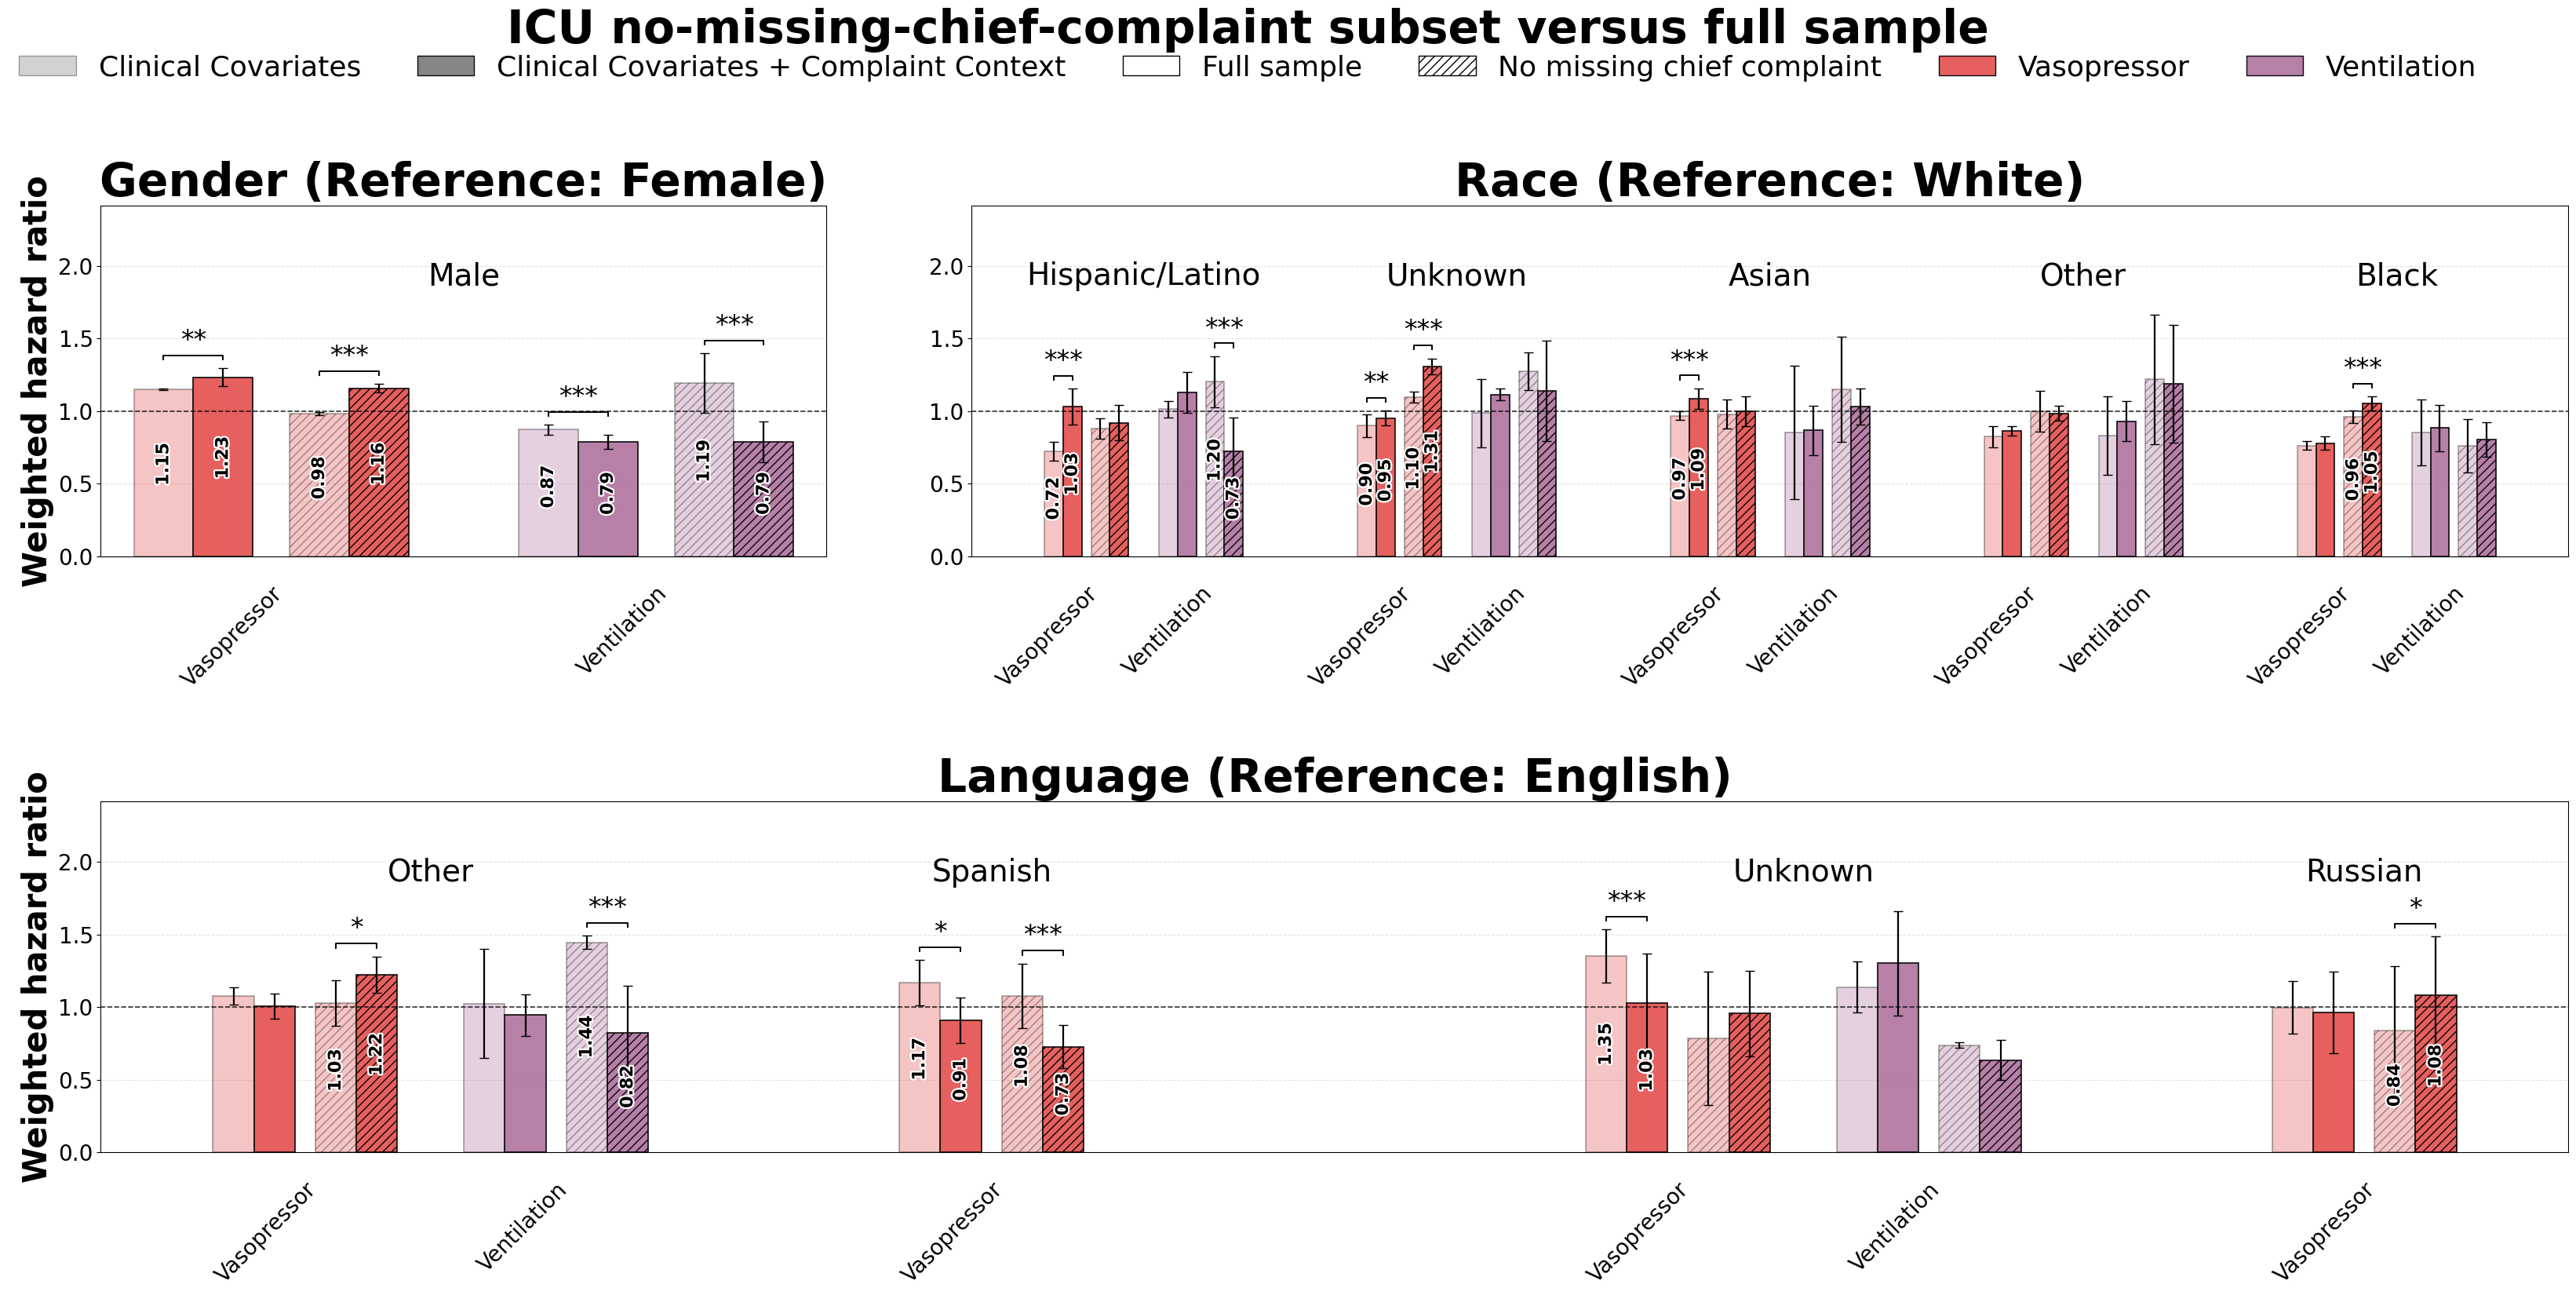

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
from scipy.stats import norm

summary = summary.copy()

summary["sample"] = summary["sample"].replace({
    "recorded_complaint_subset": "no_cc"
})

if "text_associated_shift_logHR" not in summary.columns:
    summary["text_associated_shift_logHR"] = summary["text_associated_shift"]

if "text_associated_shift_logHR_ci_low" not in summary.columns:
    summary["text_associated_shift_logHR_ci_low"] = summary["text_associated_shift_ci_low"]

if "text_associated_shift_logHR_ci_high" not in summary.columns:
    summary["text_associated_shift_logHR_ci_high"] = summary["text_associated_shift_ci_high"]


FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TITLE_FS = 42
LABEL_FS = 30
TICK_FS = 20
ANNO_FS = 24
TOPLABEL_FS = 28
BARLABEL_FS = 16
LEGEND_FS = 26

GROUP_ORDER = ["gender", "race", "language"]
DATASETS = ["pressor", "vent"]

GROUP_TITLE_MAP = {
    "gender": "Gender",
    "race": "Race",
    "language": "Language",
}

REF_MAP = {
    "gender": "Female",
    "race": "White",
    "language": "English",
}

OUTCOME_MAP = {
    "time_to_pressor_hours": "Vasopressor",
    "time_to_vent_hours": "Ventilation",
}

OUTCOME_ORDER = [
    "time_to_pressor_hours",
    "time_to_vent_hours",
]

OUTCOME_TO_COLOR = {
    "time_to_pressor_hours": "#E45756",
    "time_to_vent_hours": "#B279A2",
}

SAMPLE_LABELS = {
    "full_sample": "Full sample",
    "no_cc": "No missing chief complaint",
}

MODEL_LABELS = {
    "structured": "Structured",
    "structured_plus_text": "Structured + text",
}

SPACING_CFG = {
    "gender": {"bar_w": 0.13, "sample_gap": 0.34, "outcome_gap": 0.84, "label_gap": 1.15},
    "race": {"bar_w": 0.16, "sample_gap": 0.40, "outcome_gap": 0.98, "label_gap": 0.72},
    "language": {"bar_w": 0.16, "sample_gap": 0.40, "outcome_gap": 0.98, "label_gap": 0.72},
}


def p_to_stars_from_ci(delta_lo, delta_hi, ci=0.95):
    if pd.isna(delta_lo) or pd.isna(delta_hi):
        return ""

    z_crit = norm.ppf(1 - (1 - ci) / 2)
    se = (delta_hi - delta_lo) / (2 * z_crit)

    if not np.isfinite(se) or se <= 0:
        return ""

    est = (delta_hi + delta_lo) / 2
    z = abs(est / se)
    p = 2 * (1 - norm.cdf(z))

    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""


def split_group_and_level(term):
    term = str(term)
    for group_var in GROUP_ORDER:
        prefix = f"{group_var}_"
        if term.startswith(prefix):
            return group_var, term[len(prefix):]
    return None, term


def pretty_level_name(term, group_var):
    _, level = split_group_and_level(term)

    if group_var == "gender":
        if level == "M":
            return "Male"
        if level == "F":
            return "Female"

    return str(level).replace("_", " ").strip().title()


def make_plot_summ(summary):
    df = summary.copy()
    df = df.loc[df["level"].astype(str) != df["ref_level"].astype(str)].copy()

    df["hr_base"] = pd.to_numeric(df["structured_HR"], errors="coerce")
    df["hr_base_lo"] = pd.to_numeric(df["structured_HR_ci_low"], errors="coerce")
    df["hr_base_hi"] = pd.to_numeric(df["structured_HR_ci_high"], errors="coerce")

    df["hr_text"] = pd.to_numeric(df["structured_plus_text_HR"], errors="coerce")
    df["hr_text_lo"] = pd.to_numeric(df["structured_plus_text_HR_ci_low"], errors="coerce")
    df["hr_text_hi"] = pd.to_numeric(df["structured_plus_text_HR_ci_high"], errors="coerce")

    df["delta"] = pd.to_numeric(df["text_associated_shift_logHR"], errors="coerce")
    df["delta_lo"] = pd.to_numeric(df["text_associated_shift_logHR_ci_low"], errors="coerce")
    df["delta_hi"] = pd.to_numeric(df["text_associated_shift_logHR_ci_high"], errors="coerce")
    df["abs_delta_disp"] = df["delta"].abs()

    df["outcome_label"] = df["outcome"].map(OUTCOME_MAP)
    df["_outcome_order"] = df["outcome"].map({x: i for i, x in enumerate(OUTCOME_ORDER)})
    df["_sample_order"] = df["sample"].map({"full_sample": 0, "no_cc": 1})

    return df.sort_values(["group_var", "term", "_outcome_order", "_sample_order"]).reset_index(drop=True)


plot_summ = make_plot_summ(summary)

global_ymax = 0.0
for group_var in GROUP_ORDER:
    sub = plot_summ.loc[plot_summ["group_var"] == group_var]
    vals = []
    vals.extend(pd.to_numeric(sub["hr_base_hi"], errors="coerce").tolist())
    vals.extend(pd.to_numeric(sub["hr_text_hi"], errors="coerce").tolist())
    vals = [v for v in vals if pd.notna(v)]
    if vals:
        global_ymax = max(global_ymax, max(vals))

global_ymax = max(global_ymax * 1.45, 1.4)
level_label_y = global_ymax * 0.84

text_effects = [
    pe.Stroke(linewidth=3.2, foreground="white"),
    pe.Normal(),
]

fig = plt.figure(figsize=(34, 18))
gs = GridSpec(2, 3, figure=fig)

gender_ax = fig.add_subplot(gs[0, 0])
race_ax = fig.add_subplot(gs[0, 1:3], sharey=gender_ax)
language_ax = fig.add_subplot(gs[1, 0:3], sharey=gender_ax)

axes = {
    "gender": gender_ax,
    "race": race_ax,
    "language": language_ax,
}

fig.subplots_adjust(
    left=0.07,
    right=0.995,
    bottom=0.17,
    top=0.84,
    wspace=0.20,
    hspace=0.70,
)

for group_var in GROUP_ORDER:
    ax = axes[group_var]
    sub = plot_summ.loc[plot_summ["group_var"] == group_var].copy()

    bar_w = SPACING_CFG[group_var]["bar_w"]
    sample_gap = SPACING_CFG[group_var]["sample_gap"]
    outcome_gap = SPACING_CFG[group_var]["outcome_gap"]
    label_gap = SPACING_CFG[group_var]["label_gap"]

    term_order = (
        sub.groupby("term")["abs_delta_disp"]
        .max()
        .sort_values(ascending=False)
        .index.tolist()
    )

    xticks = []
    xticklabels = []
    level_centers = []
    level_labels = []

    x_cursor = 0.0

    for term in term_order:
        term_df = sub.loc[sub["term"] == term]
        outcome_positions_this_term = []

        for i_outcome, outcome in enumerate(OUTCOME_ORDER):
            outcome_df = term_df.loc[term_df["outcome"] == outcome]
            if outcome_df.empty:
                continue

            c = OUTCOME_TO_COLOR[outcome]
            x_outcome = x_cursor + i_outcome * outcome_gap

            for i_sample, sample_name in enumerate(["full_sample", "no_cc"]):
                row_df = outcome_df.loc[outcome_df["sample"] == sample_name]
                if row_df.empty:
                    continue

                row = row_df.iloc[0]

                x_sample = x_outcome + (i_sample - 0.5) * sample_gap
                x_base = x_sample - bar_w / 2
                x_text = x_sample + bar_w / 2
                hatch = "" if sample_name == "full_sample" else "///"

                base = float(row["hr_base"])
                text = float(row["hr_text"])

                base_lo = float(row["hr_base_lo"])
                base_hi = float(row["hr_base_hi"])
                text_lo = float(row["hr_text_lo"])
                text_hi = float(row["hr_text_hi"])

                ax.bar(
                    x_base,
                    base,
                    width=bar_w,
                    color=c,
                    alpha=0.35,
                    edgecolor="black",
                    linewidth=1.2,
                    hatch=hatch,
                    zorder=2,
                )

                ax.bar(
                    x_text,
                    text,
                    width=bar_w,
                    color=c,
                    alpha=0.95,
                    edgecolor="black",
                    linewidth=1.2,
                    hatch=hatch,
                    zorder=2,
                )

                ax.errorbar(
                    x_base,
                    base,
                    yerr=[[base - base_lo], [base_hi - base]],
                    fmt="none",
                    ecolor="black",
                    elinewidth=1.6,
                    capsize=4,
                    zorder=3,
                )

                ax.errorbar(
                    x_text,
                    text,
                    yerr=[[text - text_lo], [text_hi - text]],
                    fmt="none",
                    ecolor="black",
                    elinewidth=1.6,
                    capsize=4,
                    zorder=3,
                )

                stars = p_to_stars_from_ci(row["delta_lo"], row["delta_hi"])

                if stars:
                    yb = max(base_hi, text_hi) + 0.025 * global_ymax
                    h = 0.012 * global_ymax

                    ax.plot(
                        [x_base, x_base, x_text, x_text],
                        [yb, yb + h, yb + h, yb],
                        color="black",
                        linewidth=1.4,
                        zorder=4,
                    )

                    ax.text(
                        (x_base + x_text) / 2,
                        yb + h + 0.004 * global_ymax,
                        stars,
                        ha="center",
                        va="bottom",
                        fontsize=ANNO_FS,
                        zorder=5,
                    )

                    ax.text(
                        x_base,
                        max(base * 0.55, 0.10),
                        f"{base:.2f}",
                        ha="center",
                        va="center",
                        rotation=90,
                        fontsize=BARLABEL_FS,
                        fontweight="bold",
                        color="black",
                        path_effects=text_effects,
                        zorder=5,
                    )

                    ax.text(
                        x_text,
                        max(text * 0.55, 0.10),
                        f"{text:.2f}",
                        ha="center",
                        va="center",
                        rotation=90,
                        fontsize=BARLABEL_FS,
                        fontweight="bold",
                        color="black",
                        path_effects=text_effects,
                        zorder=5,
                    )

            xticks.append(x_outcome)
            xticklabels.append(OUTCOME_MAP[outcome])
            outcome_positions_this_term.append(x_outcome)

        if outcome_positions_this_term:
            level_centers.append(np.mean(outcome_positions_this_term))
            level_labels.append(pretty_level_name(term, group_var))

        x_cursor += len(OUTCOME_ORDER) * outcome_gap + label_gap

    ax.set_title(
        f"{GROUP_TITLE_MAP[group_var]} (Reference: {REF_MAP[group_var]})",
        fontsize=TITLE_FS,
        fontweight="bold",
    )

    ax.set_xticks(xticks)
    ax.set_xticklabels(
        xticklabels,
        rotation=45,
        ha="right",
        rotation_mode="anchor",
        fontsize=TICK_FS,
    )

    ax.tick_params(axis="x", length=0, pad=24)
    ax.tick_params(axis="y", labelsize=TICK_FS)

    ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.35)
    ax.set_axisbelow(True)
    ax.set_ylim(0, global_ymax)
    ax.axhline(1.0, linestyle="--", linewidth=1.2, color="black", alpha=0.8)

    for xpos, lbl in zip(level_centers, level_labels):
        ax.text(
            xpos,
            level_label_y,
            lbl,
            ha="center",
            va="top",
            fontsize=TOPLABEL_FS,
        )

gender_ax.set_ylabel(
    "Weighted hazard ratio",
    fontsize=LABEL_FS,
    fontweight="bold",
)

language_ax.set_ylabel(
    "Weighted hazard ratio",
    fontsize=LABEL_FS,
    fontweight="bold",
)

fig.suptitle(
    "ICU no-missing-chief-complaint subset versus full sample",
    fontsize=TITLE_FS,
    fontweight="bold",
)

legend_model = [
    Patch(facecolor="gray", edgecolor="black", alpha=0.35, label="Clinical Covariates"),
    Patch(facecolor="gray", edgecolor="black", alpha=0.95, label="Clinical Covariates + Complaint Context"),
]

legend_sample = [
    Patch(facecolor="white", edgecolor="black", hatch="", label="Full sample"),
    Patch(facecolor="white", edgecolor="black", hatch="///", label="No missing chief complaint"),
]

legend_outcome = [
    Patch(facecolor=OUTCOME_TO_COLOR[outcome], edgecolor="black", alpha=0.95, label=OUTCOME_MAP[outcome])
    for outcome in OUTCOME_ORDER
]

fig.legend(
    handles=legend_model + legend_sample + legend_outcome,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.965),
    ncol=6,
    frameon=False,
    fontsize=LEGEND_FS,
)

plt.savefig(
    FIG_DIR / "icu_no_cc.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.show()